<a href="https://colab.research.google.com/github/DancesWChickens/DBSA-UTAustin/blob/main/DSBA_Project_ET_EasyVisa_Fullcode_Final_Bricker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from datetime import datetime
from sklearn.linear_model import LogisticRegression


In [ ]:
# convert ipnb to HTML file
#%cd /content/drive/MyDrive/Colab\ Notebooks


#!jupyter nbconvert DSBA_Project_ET_EasyVisa_Fullcode_Final_Bricker.ipynb --to html


/content/drive/MyDrive/Colab Notebooks
[NbConvertApp] Converting notebook DSBA_Project_ET_EasyVisa_Fullcode_Final_Bricker.ipynb to html
[NbConvertApp] Writing 4151303 bytes to DSBA_Project_ET_EasyVisa_Fullcode_Final_Bricker.html


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# read the dataset
data=pd.read_csv('/content/drive/My Drive/UTAustinDataScience/datafiles/EasyVisa.csv')

## Data Overview

- Observations
- Sanity checks

###Plot function setup

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
#set up a custom function for graphs
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined


    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=60, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
#view first few rows
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


Insight: There are negative numbers in the no_of_employees columns.

In [ ]:
data.shape

(25480, 12)

####Insight
There are 25480 rows and 12 columns. 9 are of type "object" and 3 are integers.

###Converting objects to categorical strings

In [ ]:
for feature in data.columns: # Loop through all columns in the dataframe
    if data[feature].dtype == 'object': # Only apply for columns with categorical strings
        data[feature] = pd.Categorical(data[feature])# Replace strings with an integer
data.head(10)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.3900,Year,Y,Certified
7,EZYV08,North America,Bachelor's,Y,N,3035,1924,West,418.2298,Hour,Y,Denied
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.1900,Year,Y,Certified
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.7600,Year,Y,Certified


####Insight
Viewing negative employee numbers. These will need to be converted to positive numbers.

In [ ]:
data.loc[data['no_of_employees']<0]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [ ]:
data.duplicated().sum()

0

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# Check if all case IDs are unique
all_unique = data['case_id'].is_unique

# Print the result
print(f"All case IDs are unique: {all_unique}")


All case IDs are unique: True


In [ ]:
data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


No data or case_ids are duplicated. There are no issues with null or n/a values.

#Univariate Analysis

###Continents

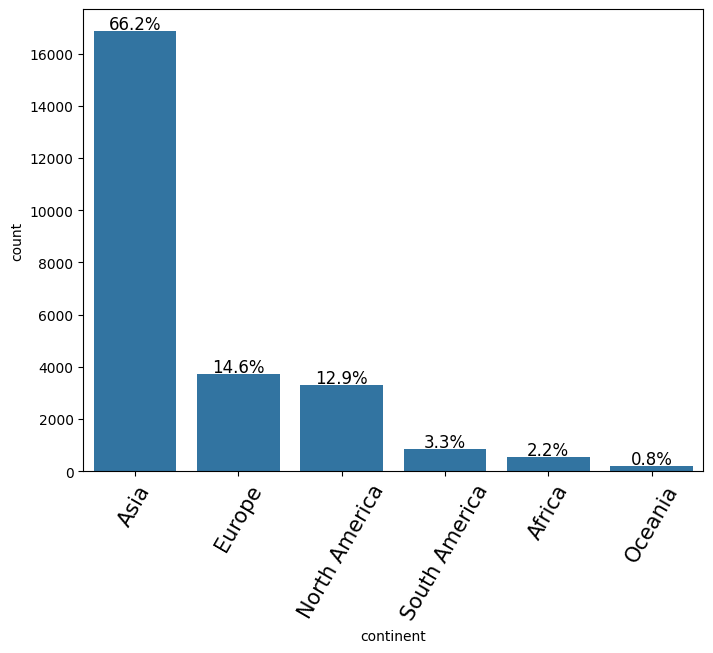

In [ ]:
labeled_barplot(data, "continent", perc=True)

####Insight
The vast majority of candidates come from Asia. Europe and North America are next at 14.6% and 12.9% respectively.

###Education

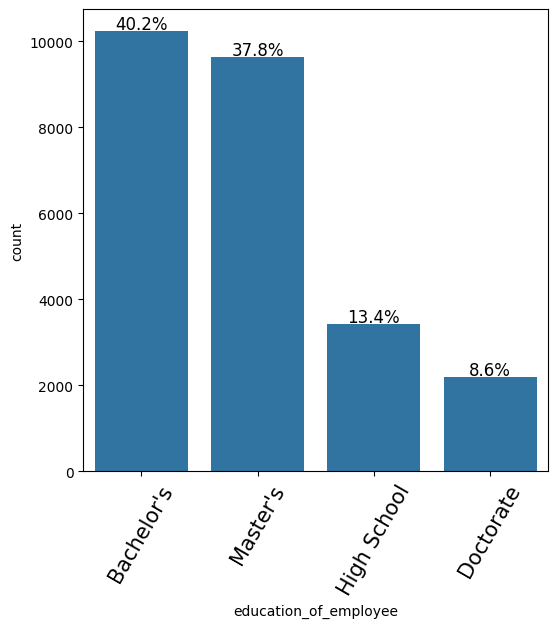

In [ ]:

labeled_barplot(data, "education_of_employee", perc=True)


####Insight
Most candidates have advanced degrees. Only 13.4% do not have a college education.

###Job Experience

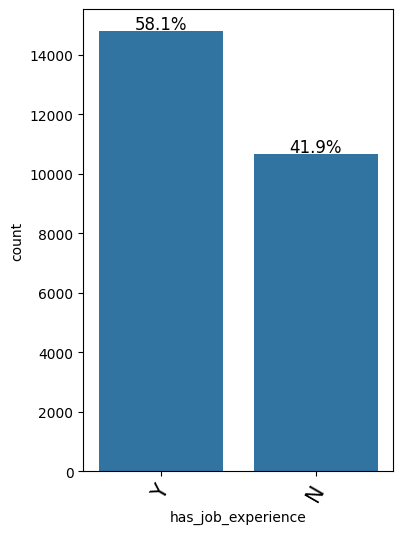

In [ ]:

labeled_barplot(data, "has_job_experience", perc=True)



####Insight
58.1 % of candidates have prior job experience.

###Job Traing Required

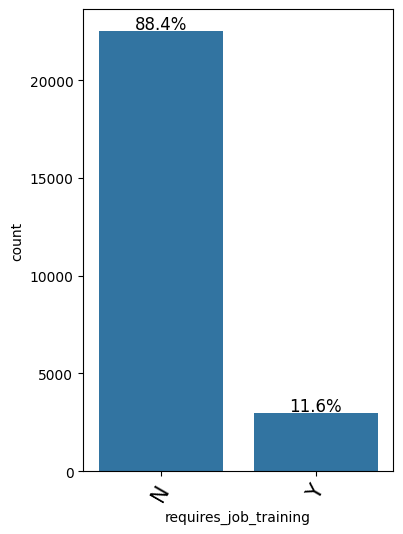

In [ ]:
labeled_barplot(data, "requires_job_training", perc=True)


####Insight
Most candidates (88.4%) require job training.

###No of Employees

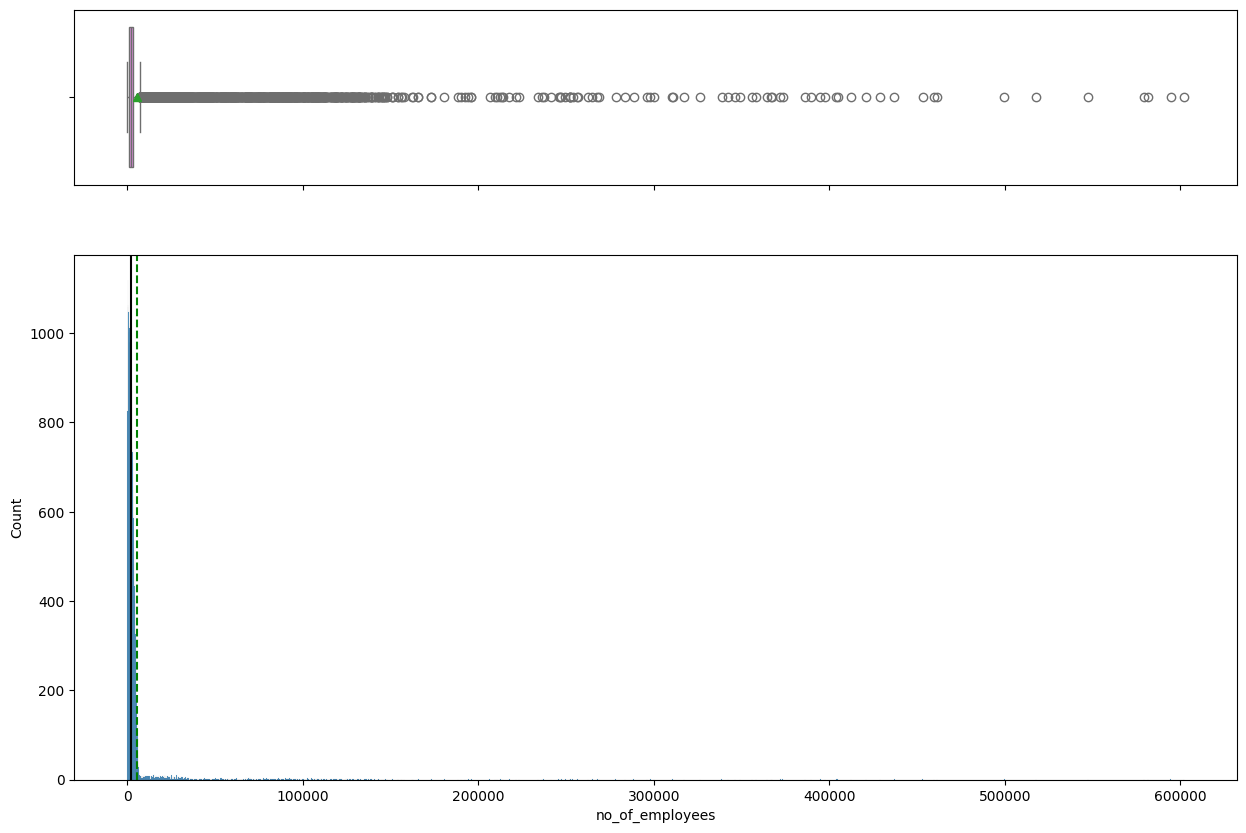

In [ ]:
# graph number of employees

histogram_boxplot(data, "no_of_employees")


####Insight
These charts are heavily skewed, but there are some extremely large companies out there, so I hesitate to remove these outliers. Quick research on google showed that companies like Walmart, Accenture, Volkswagen and others can have 600k to a million employees.

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


###Hourly Wage

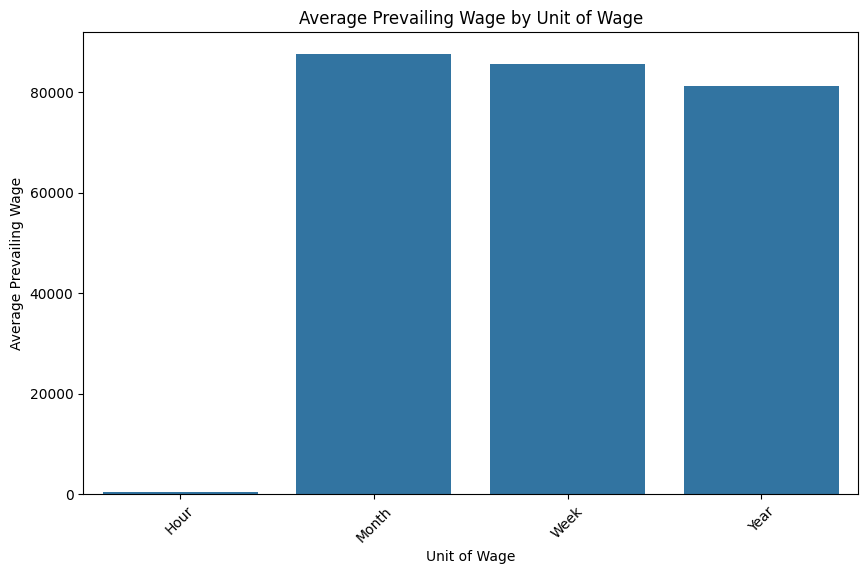

In [ ]:
wage_grouped = data.groupby('unit_of_wage')['prevailing_wage'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='unit_of_wage', y='prevailing_wage', data=wage_grouped)
plt.title('Average Prevailing Wage by Unit of Wage')
plt.xlabel('Unit of Wage')
plt.ylabel('Average Prevailing Wage')
plt.xticks(rotation=45)
plt.show()


####Insight
There are many outliers in the respective categories. These will need to be removed/dealt with in pre-processing.

###Year of Establishment

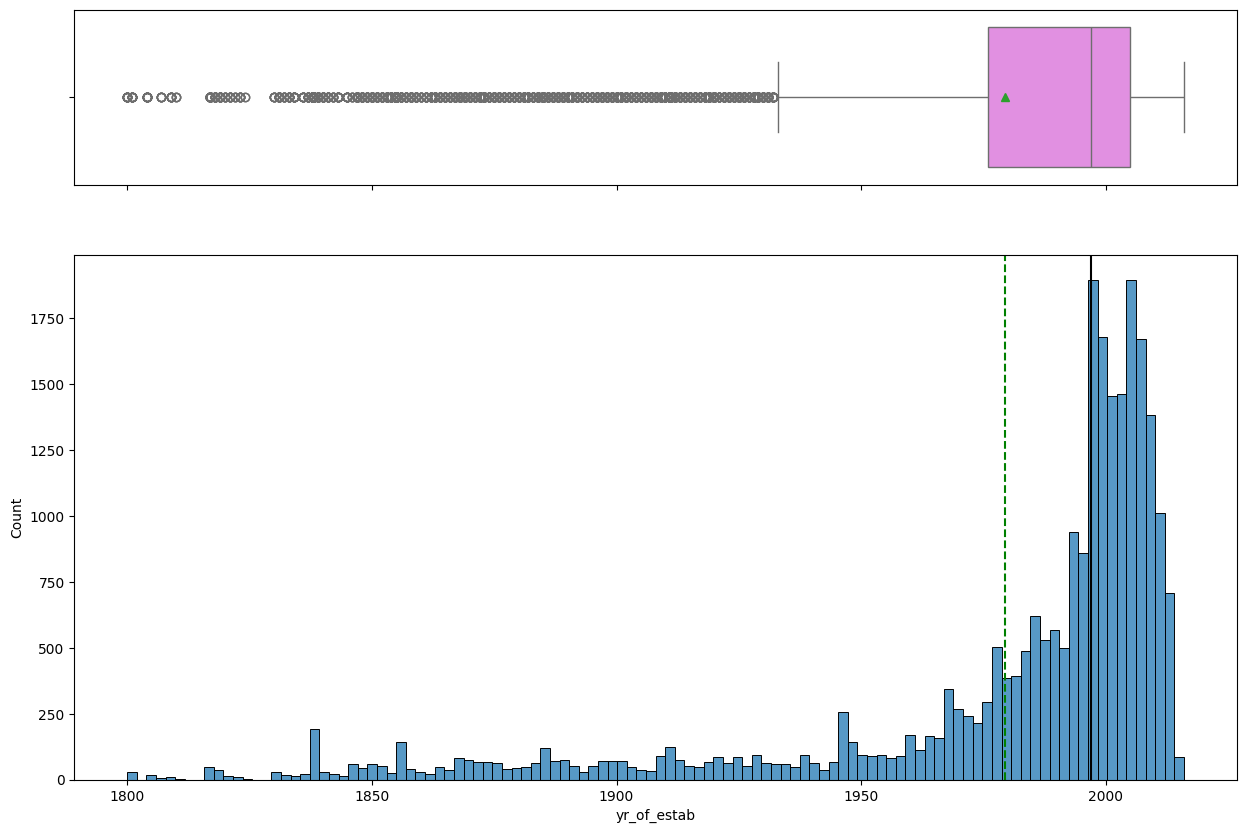

In [ ]:
histogram_boxplot(data, "yr_of_estab")

####Insight
The data is very skewed. There are a few very old companies. Most were started after the year 2000.

###Full time position

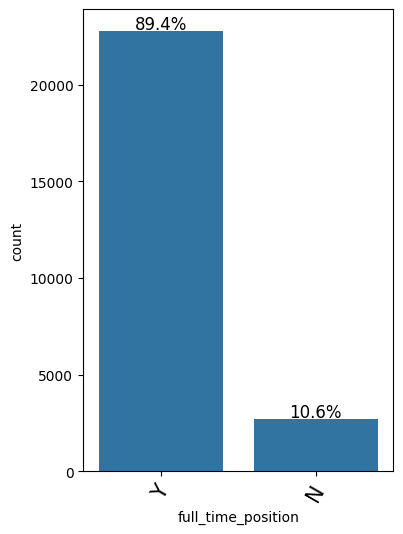

In [ ]:


labeled_barplot(data, "full_time_position", perc=True)


####The vast majority of cases (89.4%) are full time.

###Case Status

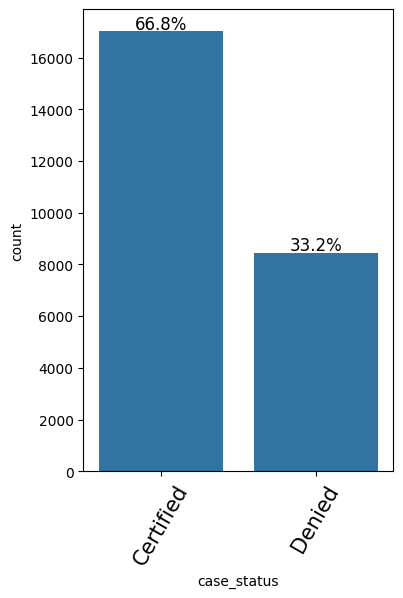

In [ ]:
labeled_barplot(data, "case_status", perc=True)

####Insight
66.8% of cases get certified. 33.2% (roughly one-third) are denied.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
# drop caseid column. Doing this pre-processing early so it does not cause an issue with bivariate analysis later

data = data.drop('case_id', axis=1)


In [ ]:
data["no_of_employees"] = abs(data["no_of_employees"])

In [ ]:
data.loc[data['no_of_employees']<0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


In [ ]:
#for feature in data.columns: # Loop through all columns in the dataframe
#    if data[feature].dtype == 'object': # Only apply for columns with categorical strings
#        data[feature] = pd.Categorical(data[feature])# Replace strings with an integer
#data.head(10)

In [ ]:
# Calculate the IQR for prevailing_wage within each unit_of_wage category

def calculate_iqr_outliers(df, column, category):
    # Group by the category and calculate Q1, Q3 and IQR
    grouped = df.groupby(category)[column].describe()
    Q1 = grouped['25%']
    Q3 = grouped['75%']
    IQR = Q3 - Q1

    # Determine outlier thresholds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    df['is_outlier'] = df.apply(lambda row: row[column] < lower_bound[row[category]]
                                               or row[column] > upper_bound[row[category]], axis=1)
    return df, lower_bound, upper_bound

# Apply the IQR method to detect outliers in prevailing_wage for each unit_of_wage
data_with_outliers, lower_bounds, upper_bounds = calculate_iqr_outliers(data, 'prevailing_wage', 'unit_of_wage')

# Display the number of outliers detected in each unit_of_wage category
outlier_summary = data_with_outliers.groupby('unit_of_wage')['is_outlier']
outlier_summary

In [ ]:
# Function to cap the outliers at the upper bound
def cap_outliers(df, column, category, upper_bounds):
    df['capped_prevailing_wage'] = df.apply(lambda row: min(row[column], upper_bounds[row[category]]), axis=1)
    return df

# Cap the outliers at the upper bound for prevailing_wage in each unit_of_wage category
data_capped = cap_outliers(data_with_outliers, 'prevailing_wage', 'unit_of_wage', upper_bounds)

# Display the updated data to confirm the capping process
data_capped[data_capped['is_outlier'] == True][['prevailing_wage', 'unit_of_wage', 'capped_prevailing_wage']].head(10)



,prevailing_wage,unit_of_wage,capped_prevailing_wage
14,220081.73,Year,212780.9675
34,225569.73,Year,212780.9675
130,247393.01,Year,212780.9675
216,269321.68,Year,212780.9675
221,219529.62,Year,212780.9675
325,232227.33,Year,212780.9675
328,238691.32,Year,212780.9675
348,220448.17,Year,212780.9675
427,230750.48,Year,212780.9675
457,235339.91,Year,212780.9675


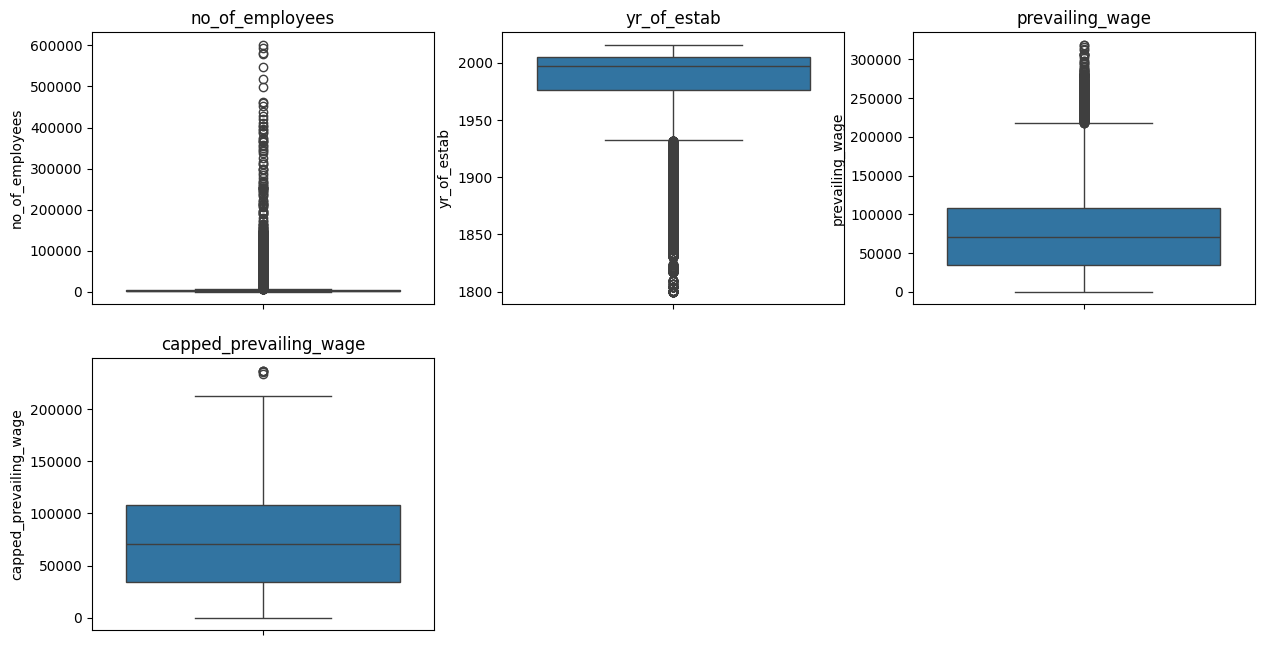

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data[variable])
    plt.title(variable)
plt.show()

The fact that wage is stated in different units makes it difficult to do meaningful comparisons, therefore, I will convert them all to hours.

The number of employees looks suspiciously high, but after doing some research on Google, I did find that walmart, for example, has over 1 million employees, Accenture has over 700,000, Volkswagen has over 680,000, etc. So these numbers could be real. I will leave them as-is.

###Dropping prevailing wage after creating a new column called "capped prevailing wage" to deal with outliers.

In [ ]:
data = data.drop('prevailing_wage', axis=1)

###Year of estab conversion
Converting to age to avoid calculations on years

In [ ]:
def age (yr_of_estab):
  current_year = datetime.now().year
  return current_year-yr_of_estab


In [ ]:
data['age_of_company'] = data['yr_of_estab'].apply(age)
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,unit_of_wage,full_time_position,case_status,is_outlier,capped_prevailing_wage,age_of_company
0,Asia,High School,N,N,14513,2007,West,Hour,Y,Denied,False,592.2029,17
1,Asia,Master's,Y,N,2412,2002,Northeast,Year,Y,Certified,False,83425.6500,22
2,Asia,Bachelor's,N,Y,44444,2008,West,Year,Y,Denied,False,122996.8600,16
3,Asia,Bachelor's,N,N,98,1897,West,Year,Y,Denied,False,83434.0300,127
4,Africa,Master's,Y,N,1082,2005,South,Year,Y,Certified,False,149907.3900,19


In [ ]:
data.drop('yr_of_estab',axis=1,inplace=True)

###Dealing with units of wage and salary calculations

In [ ]:
data['unit_of_wage'].unique()

['Hour', 'Year', 'Week', 'Month']
Categories (4, object): ['Hour', 'Month', 'Week', 'Year']

In [ ]:
conversion_factors = {
    'Hour': 1,
    'Week': 1 / 40,       # Assuming 40 hours per week
    'Month': 1 / (160),   # Assuming 160 hours per month (40 hours * 4 weeks)
    'Year': 1 / 2080      # Assuming 2080 hours per year (40 hours * 52 weeks)
}

# Normalize to hourly rate
data['capped_wage_hourly'] = data.apply(
    lambda row: row['capped_prevailing_wage'] * conversion_factors[row['unit_of_wage']],
    axis=1
)



In [ ]:
data.drop(['capped_prevailing_wage'],axis=1,inplace=True)

In [ ]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,unit_of_wage,full_time_position,case_status,is_outlier,age_of_company,capped_wage_hourly
0,Asia,High School,N,N,14513,West,Hour,Y,Denied,False,17,592.202900
1,Asia,Master's,Y,N,2412,Northeast,Year,Y,Certified,False,22,40.108486
2,Asia,Bachelor's,N,Y,44444,West,Year,Y,Denied,False,16,59.133106
3,Asia,Bachelor's,N,N,98,West,Year,Y,Denied,False,127,40.112514
4,Africa,Master's,Y,N,1082,South,Year,Y,Certified,False,19,72.070861


### Wage Conversion

Since we have converted all wages to hours, I want to avoid confusion that could be caused by the unit of wage column. I will rename it to pay interval so we can preserve the information, but we also know that we are not stating salaries in anything but hours anymore.

In [ ]:
#  rename unit of wage to pay period since we are not stating salaries in anything but hours now

data.rename(columns={'unit_of_wage': 'pay_interval'}, inplace=True)


####Dealing with additional wage issues.
There is still a problem with this capped wage. This time I am going to get rid of the outliers completely.

###Encoding

In [ ]:

# Encode categorical variables using LabelEncoder for binary categories and OneHotEncoder for others
label_enc_cols = ['has_job_experience', 'requires_job_training', 'full_time_position', 'case_status']
onehot_enc_cols = ['continent', 'education_of_employee', 'region_of_employment', 'pay_interval']

# Apply Label Encoding
label_encoders = {}
for col in label_enc_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Apply OneHot Encoding
data_encoded = pd.get_dummies(data, columns=onehot_enc_cols, drop_first=True)




In [ ]:
data_encoded.head()

,has_job_experience,requires_job_training,no_of_employees,full_time_position,case_status,is_outlier,age_of_company,capped_wage_hourly,continent_Asia,continent_Europe,...,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,pay_interval_Month,pay_interval_Week,pay_interval_Year
0,0,0,14513,1,1,False,17,592.202900,True,False,...,False,True,False,False,False,False,True,False,False,False
1,1,0,2412,1,0,False,22,40.108486,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,1,44444,1,1,False,16,59.133106,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0,98,1,1,False,127,40.112514,True,False,...,False,False,False,False,False,False,True,False,False,True
4,1,0,1082,1,0,False,19,72.070861,False,False,...,False,False,True,False,False,True,False,False,False,True


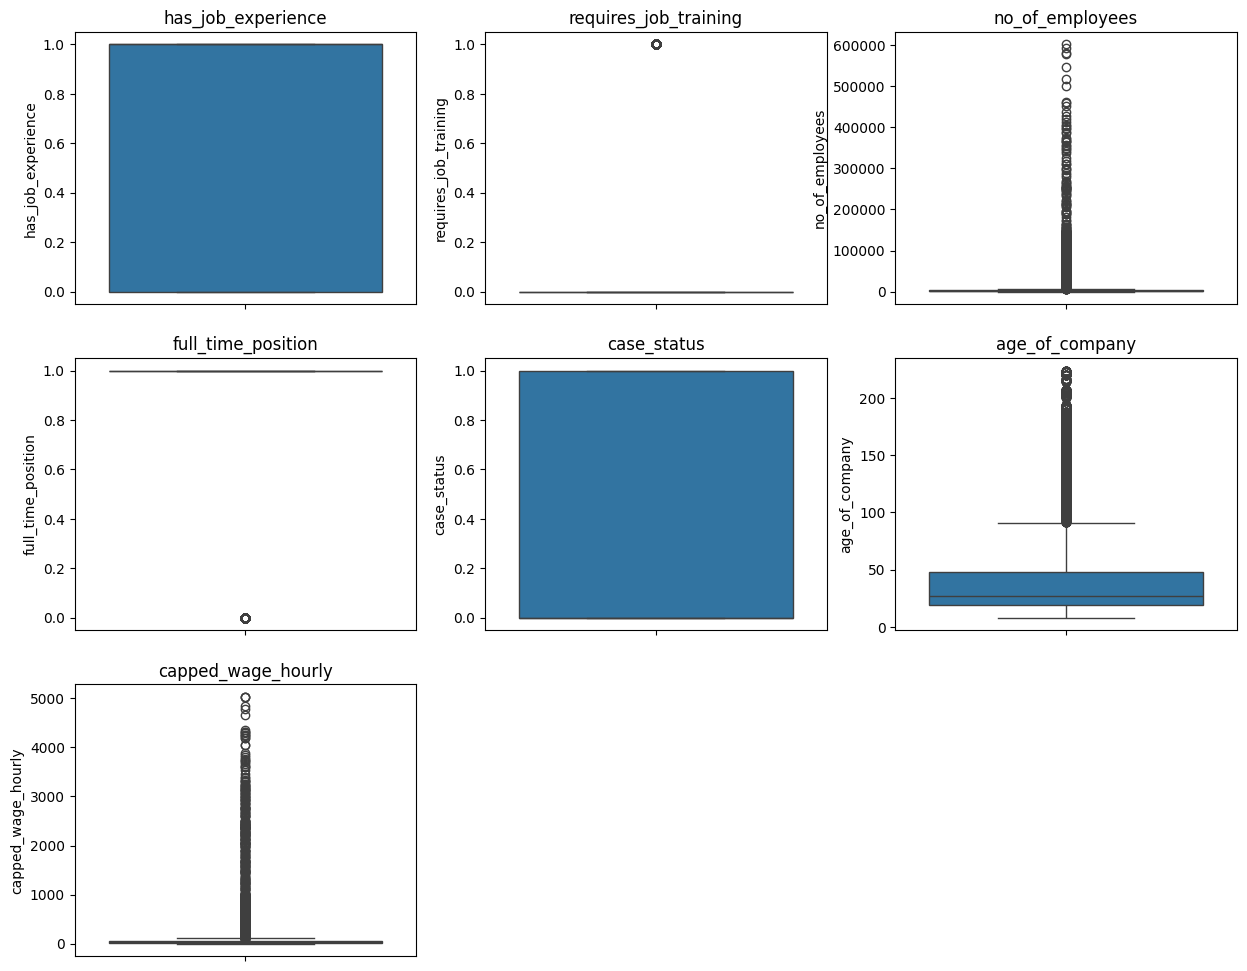

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data[variable])
    plt.title(variable)
plt.show()

In [ ]:
# get rid of outliers in capped_wage_hourly

# Calculate IQR for capped_wage_hourly
Q1 = data_encoded['capped_wage_hourly'].quantile(0.25)
Q3 = data_encoded['capped_wage_hourly'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
data_no_outliers = data_encoded[(data_encoded['capped_wage_hourly'] >= lower_bound) & (data_encoded['capped_wage_hourly'] <= upper_bound)]

# Display the shape of the data before and after removing outliers
print("Shape before removing outliers:", data_encoded.shape)
print("Shape after removing outliers:", data_no_outliers.shape)


Shape before removing outliers: (25480, 23)
Shape after removing outliers: (23316, 23)


In [ ]:
# prompt: export data_encoded to my drive

#data_encoded.to_csv('/content/drive/My Drive/visa_data_encoded.csv', index=False)


In [ ]:
data_no_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
has_job_experience,23316.0,0.595342,0.490836,0.000000,0.000000,1.000000,1.000000,1.00
requires_job_training,23316.0,0.124164,0.329775,0.000000,0.000000,0.000000,0.000000,1.00
no_of_employees,23316.0,5772.459684,23402.095297,11.000000,1036.000000,2143.500000,3554.250000,602069.00
full_time_position,23316.0,0.885272,0.318700,0.000000,1.000000,1.000000,1.000000,1.00
case_status,23316.0,0.306871,0.461205,0.000000,0.000000,0.000000,1.000000,1.00
age_of_company,23316.0,44.036927,41.993940,8.000000,19.000000,27.000000,47.000000,224.00
capped_wage_hourly,23316.0,39.326040,23.725316,0.048077,21.164454,36.944149,53.991078,116.04


In [ ]:
#drop the "is_outlier" column
data_no_outliers.drop(['is_outlier'],axis=1,inplace=True)

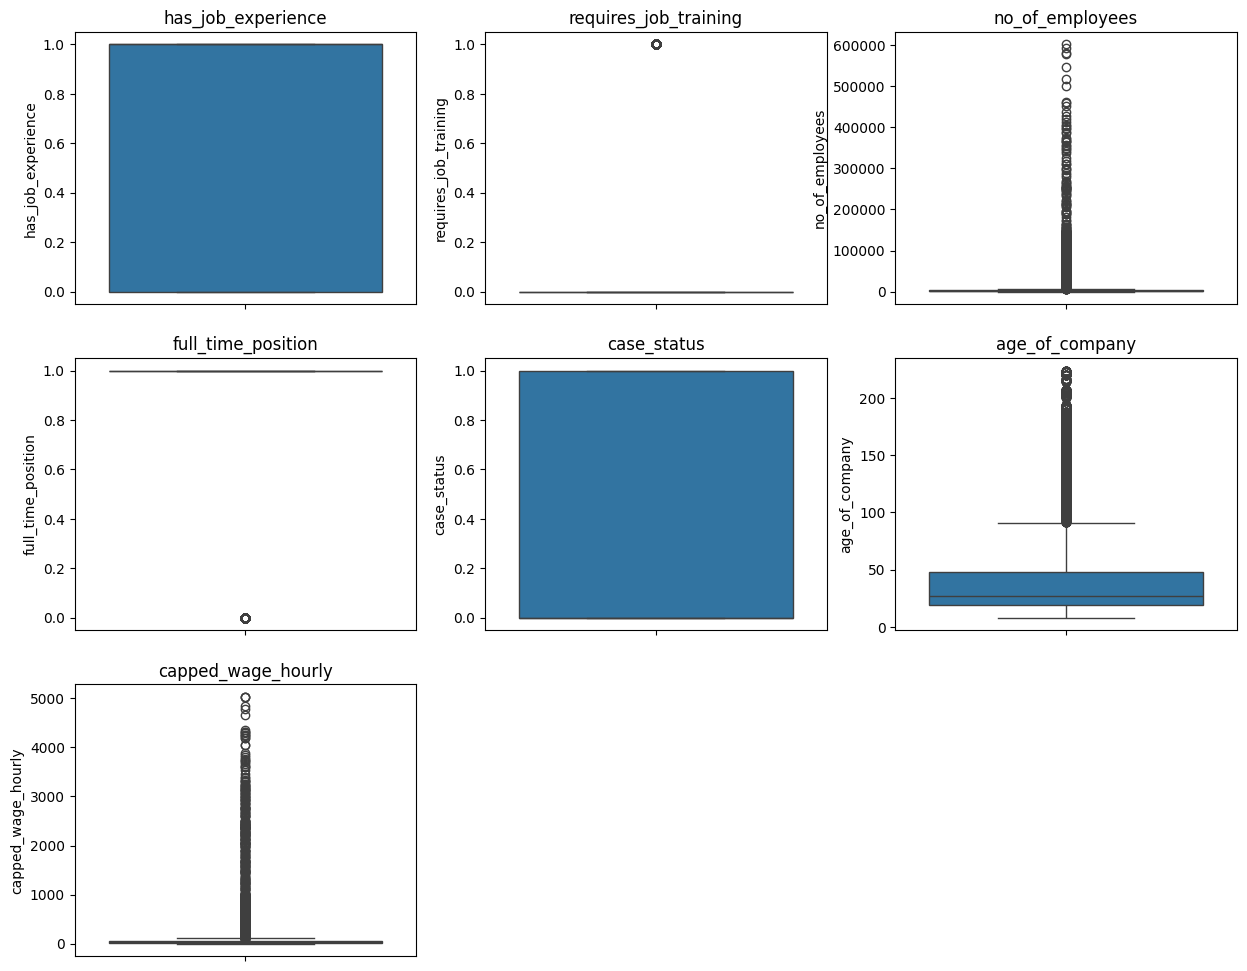

In [ ]:
# outlier detection using boxplot after removing outliers
numeric_columns = data_no_outliers.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data[variable])
    plt.title(variable)
plt.show()

#Bivariate Analysis

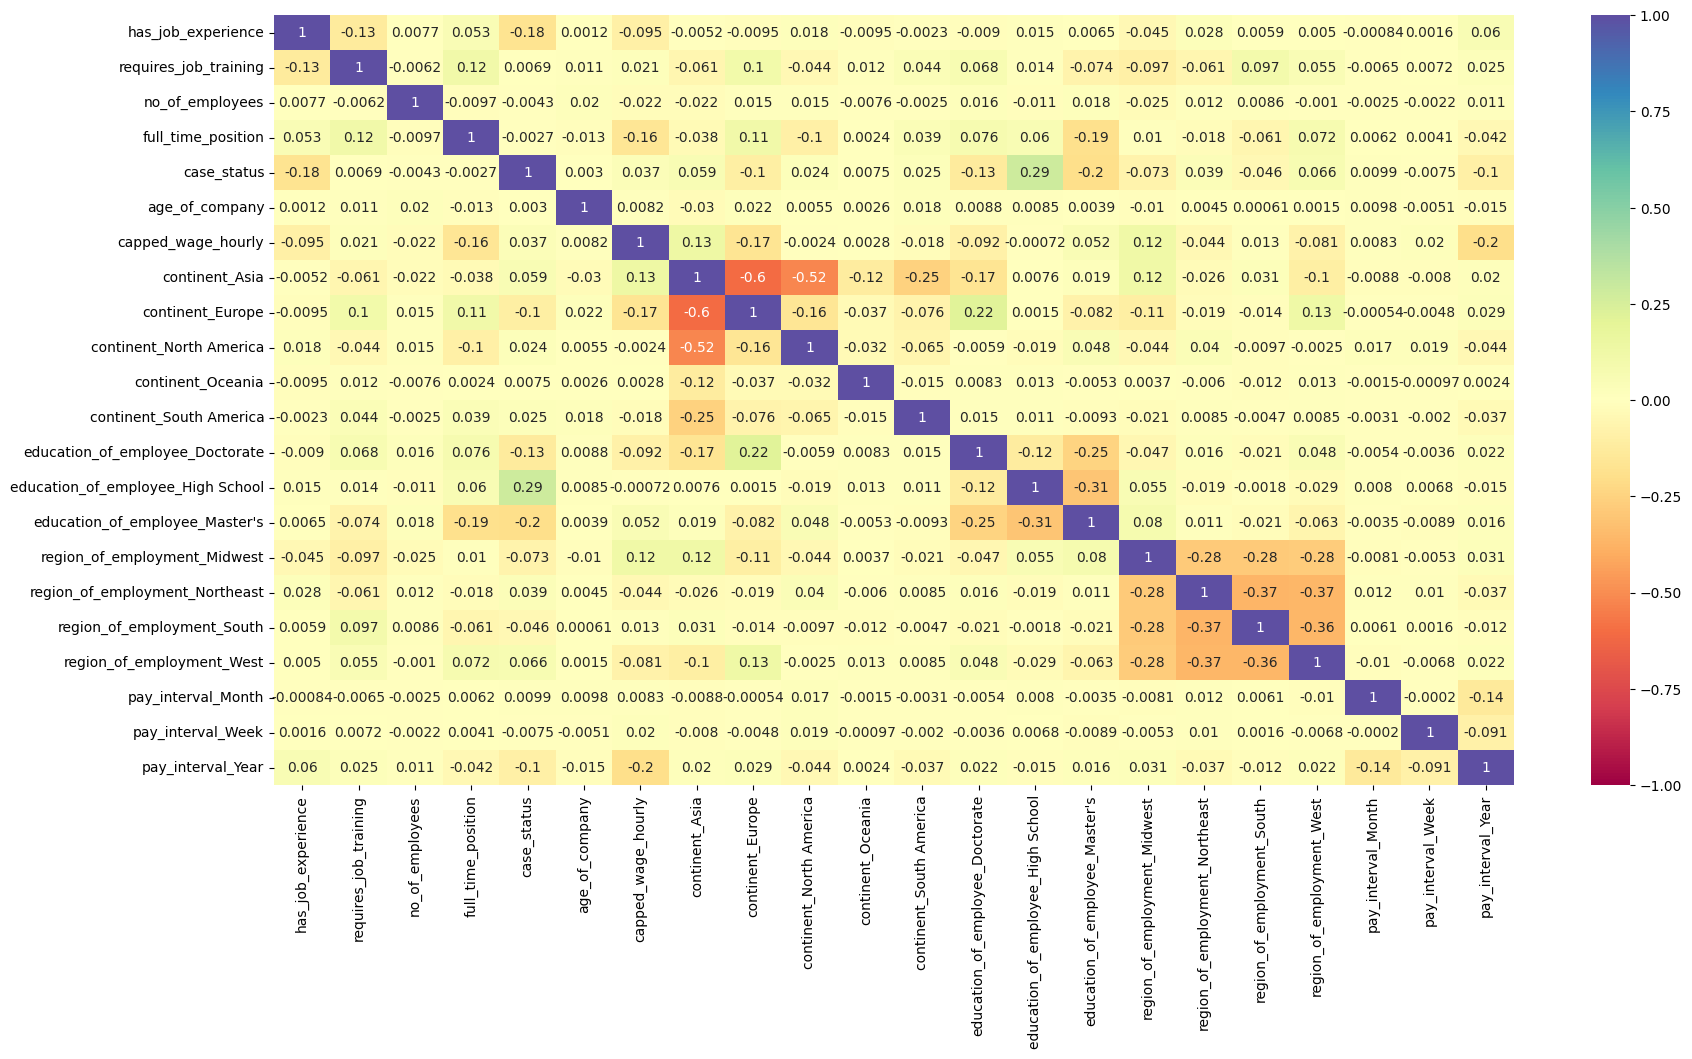

In [ ]:

plt.figure(figsize=(20,10))
# dropping yr_of_estab as it is a temporal variable

sns.heatmap(data_no_outliers.corr(),annot=True,vmin=-1,vmax=1,cmap="Spectral")
plt.show()

####Insight
There are positive correlations between case status and:


*   capped wage
*   education of employee: High School
*   education of employee: Doctorate
*   requires job training
*   continent of Asia


There are negative correlations for:


*   Certain pay intervals - Month and Year
*   education of employee: Masters







**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

###1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?


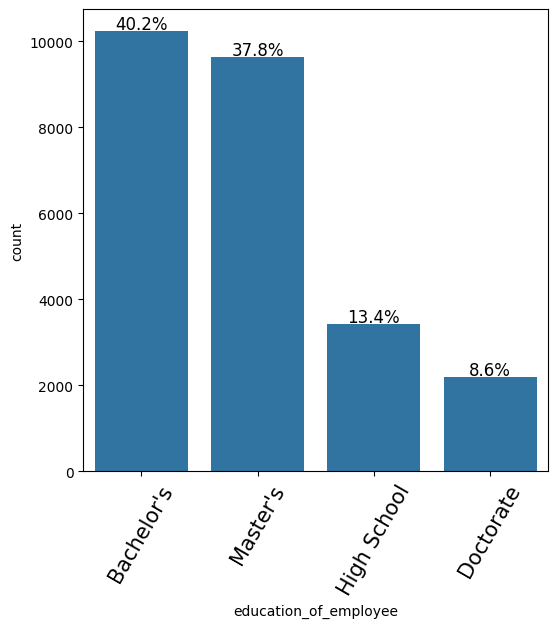

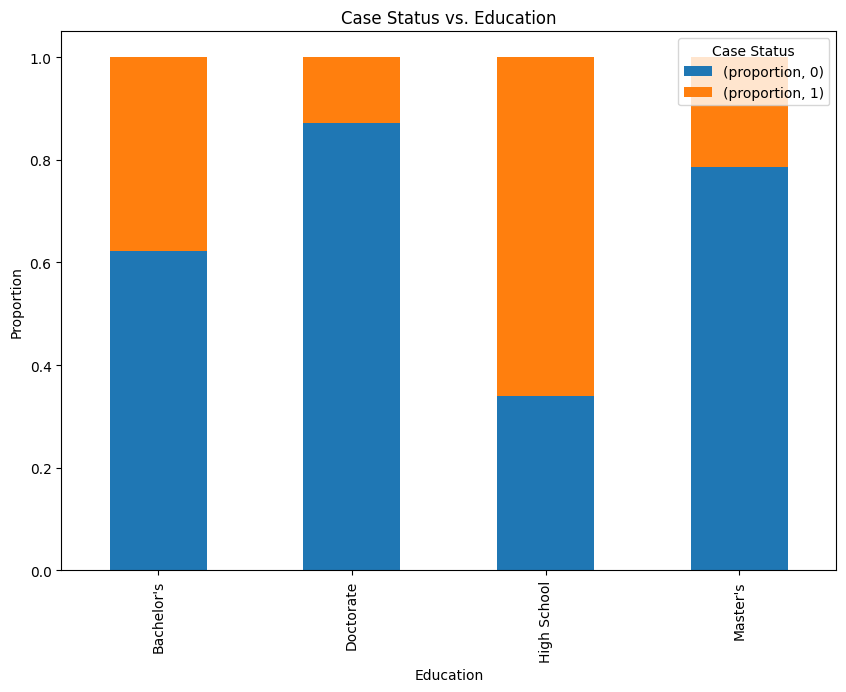

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)
experience = data.groupby(by=['education_of_employee'])['case_status'].value_counts(normalize=True).to_frame()
experience.unstack().plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Case Status vs. Education')
plt.xlabel('Education')
plt.ylabel('Proportion')
plt.legend(title='Case Status', loc='upper right')
plt.show()

####Insight
The majority of employees have advanced degrees: Bachelor's, Master's and Doctorate, repectively. Employees with a high school education make up only 13.4% of the population.

###2. How does the visa status vary across different continents?

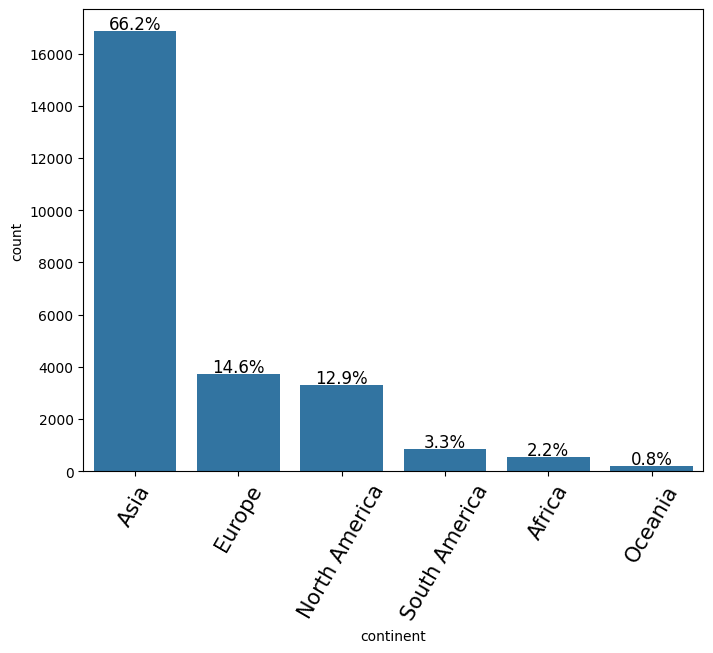

In [ ]:
labeled_barplot(data, "continent", perc=True)

####Insight

###3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

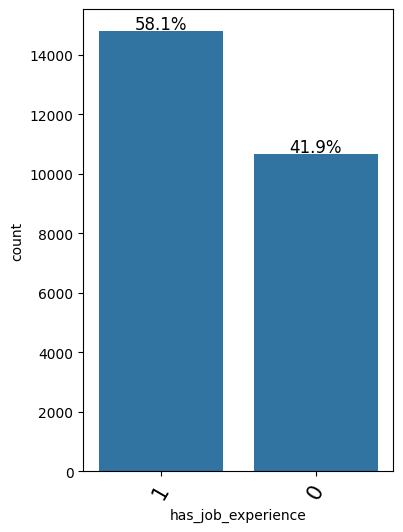

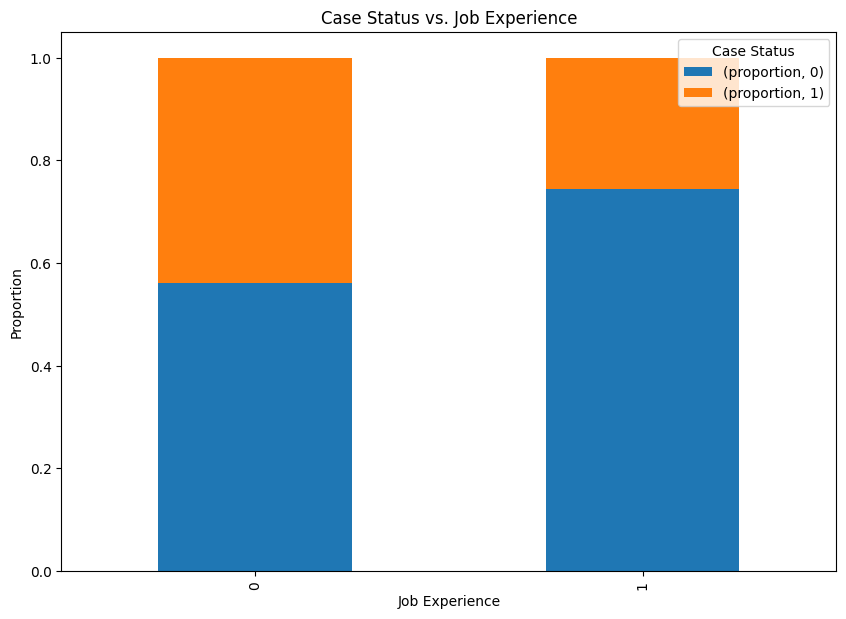

In [ ]:
labeled_barplot(data, "has_job_experience", perc=True)
experience = data.groupby(by=['has_job_experience'])['case_status'].value_counts(normalize=True).to_frame()
experience.unstack().plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Case Status vs. Job Experience')
plt.xlabel('Job Experience')
plt.ylabel('Proportion')
plt.legend(title='Case Status', loc='upper right')
plt.show()

####Insight
58.1% of the employees who get visas have prior job experience. 41.9% do not. Work experience does appear to influence visa status, but it not having experience does not seem to be a deal breaker, either.

###4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

In [ ]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,pay_interval,full_time_position,case_status,is_outlier,age_of_company,capped_wage_hourly
0,Asia,High School,0,0,14513,West,Hour,1,1,False,17,592.202900
1,Asia,Master's,1,0,2412,Northeast,Year,1,0,False,22,40.108486
2,Asia,Bachelor's,0,1,44444,West,Year,1,1,False,16,59.133106
3,Asia,Bachelor's,0,0,98,West,Year,1,1,False,127,40.112514
4,Africa,Master's,1,0,1082,South,Year,1,0,False,19,72.070861


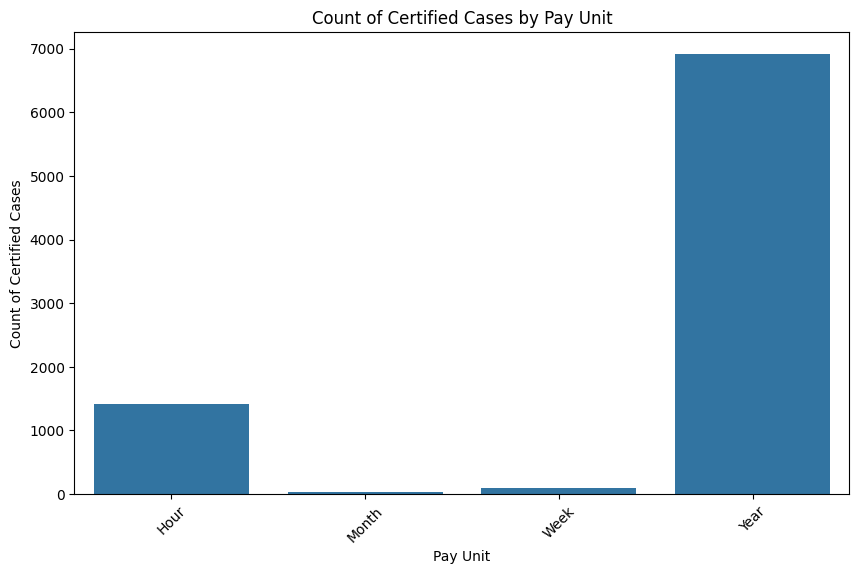

In [ ]:
#going back to un-encoded data for simplicity
certified_by_pay_unit = data[data['case_status'] == 1].groupby('pay_interval').size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.barplot(x='pay_interval', y='count', data=certified_by_pay_unit)
plt.title('Count of Certified Cases by Pay Unit')
plt.xlabel('Pay Unit')
plt.ylabel('Count of Certified Cases')
plt.xticks(rotation=45)
plt.show()

####Insight
The vast majority requests are for yearly intervals (90.1%)

###5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

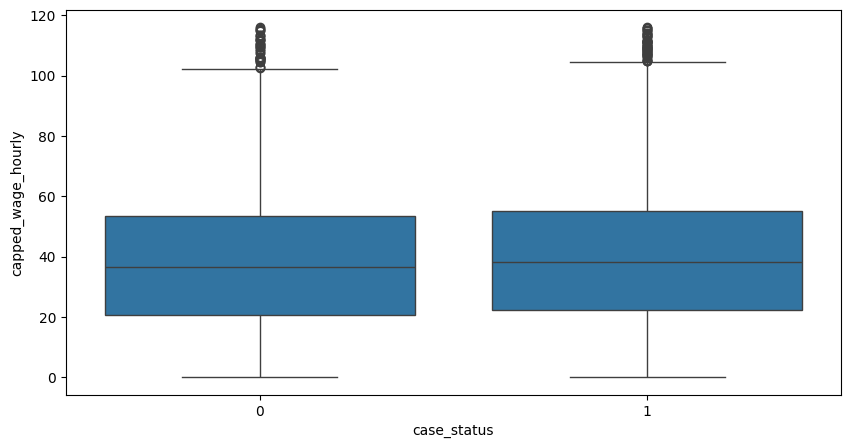

In [ ]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=data_no_outliers, x="case_status", y="capped_wage_hourly")
plt.show()


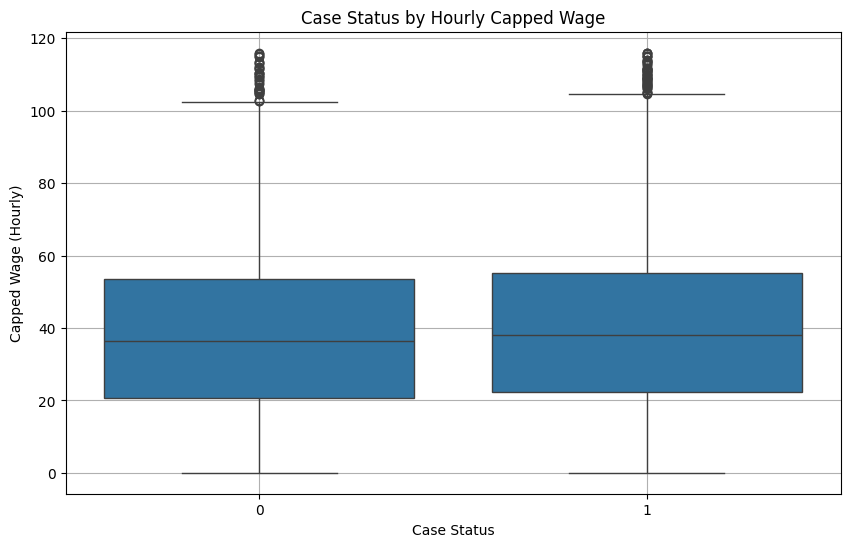

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='case_status', y='capped_wage_hourly', data=data_no_outliers)
plt.title('Case Status by Hourly Capped Wage')
plt.xlabel('Case Status')
plt.ylabel('Capped Wage (Hourly)')
plt.grid(True)
plt.show()

####Insight
There is a slight increase in visa approvals as wages rise.

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
data_no_outliers.head()

,has_job_experience,requires_job_training,no_of_employees,full_time_position,case_status,age_of_company,capped_wage_hourly,continent_Asia,continent_Europe,continent_North America,...,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,pay_interval_Month,pay_interval_Week,pay_interval_Year
1,1,0,2412,1,0,22,40.108486,True,False,False,...,False,False,True,False,True,False,False,False,False,True
2,0,1,44444,1,1,16,59.133106,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0,98,1,1,127,40.112514,True,False,False,...,False,False,False,False,False,False,True,False,False,True
4,1,0,1082,1,0,19,72.070861,False,False,False,...,False,False,True,False,False,True,False,False,False,True
5,1,0,2339,1,0,12,37.621221,True,False,False,...,False,False,True,False,False,True,False,False,False,True


# Building bagging and boosting models

##Setting up training sets and necessary functions

In [ ]:
#split the data into test and training sets

# Split the dataset into features and target
X = data_no_outliers.drop(columns=['case_status'])
y = data_no_outliers['case_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1,stratify=y)

In [ ]:
#changed to add true/false positive/negative labels so it is clearer to me

def make_confusion_matrix2(model, X_test, y_actual, labels=[1, 0]):
    '''
    model : classifier to predict values of X_test
    X_test : feature set used to make predictions
    y_actual : ground truth labels
    labels : order of labels, default is [1, 0] (Positive, Negative)
    '''
    # Predict the labels
    y_predict = model.predict(X_test)

    # Generate the confusion matrix
    cm = metrics.confusion_matrix(y_actual, y_predict, labels=[0, 1])

    # Create a DataFrame for better readability in the heatmap
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                         columns=["Predicted - No", "Predicted - Yes"])

    # Create labels for the heatmap (True Neg, False Pos, False Neg, True Pos)
    group_names = ["True Negative", "False Positive", "False Negative", "True Positive"]
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    # Plot the heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix with Labels')
    plt.show()

# Example usage:
# make_confusion_matrix(model, X_test, y_test)


In [ ]:
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    #Accuracy of the model
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)

    #Recall of the model
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)

    #Precision of the model
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))

    return score_list # returning the list with train and test scores

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

##Decision Tree

In [ ]:
dtree = DecisionTreeClassifier(random_state=1)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
dtree_estimator_model_train_perf = model_performance_classification_sklearn(dtree, X_train, y_train)
dtree_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
dtree_estimator_model_test_perf = model_performance_classification_sklearn(dtree, X_test, y_test)
dtree_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.668192,0.475082,0.460705,0.467783


In [ ]:
dtree_tuned = DecisionTreeClassifier(random_state=1)
parameters= {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10,
                       min_impurity_decrease=0.001, random_state=1)

In [ ]:
dtree_tuned_model_train_perf = model_performance_classification_sklearn(dtree_tuned, X_train, y_train)
dtree_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.738619,0.515375,0.583937,0.547518


In [ ]:
dtree_tuned_model_test_perf = model_performance_classification_sklearn(dtree, X_test, y_test)
dtree_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.668192,0.475082,0.460705,0.467783



#Bagging Classifier

In [ ]:
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(X_train,y_train)

BaggingClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_estimator_score=get_metrics_score(bagging_estimator)

Accuracy on training set :  0.9788615893633968
Accuracy on test set :  0.7232308791994282
Recall on training set :  0.9388977635782748
Recall on test set :  0.3931066604564509
Precision on training set :  0.9917738873655347
Precision on test set :  0.5714285714285714


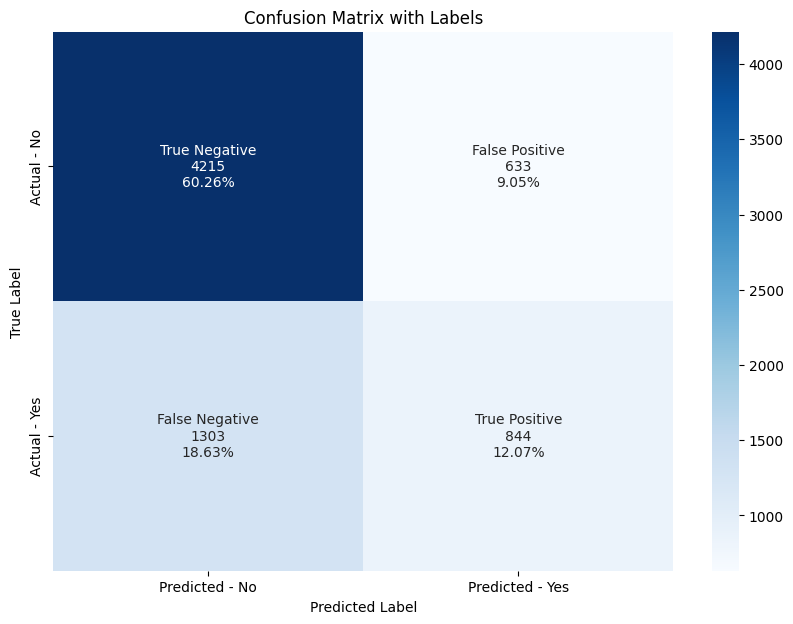

In [ ]:
make_confusion_matrix2(bagging_estimator,X_test,y_test)

In [ ]:
bagging_estimator_model_train_perf = model_performance_classification_sklearn(bagging_estimator, X_train, y_train)
dtree_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.738619,0.515375,0.583937,0.547518


In [ ]:
bagging_estimator_model_test_perf = model_performance_classification_sklearn(bagging_estimator, X_test, y_test)
bagging_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.723231,0.393107,0.571429,0.465784


###Random Forest Classifier

In [ ]:
#Train the random forest classifier
rf_estimator=RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

In [ ]:
rf_estimator_score=get_metrics_score(rf_estimator)

Accuracy on training set :  1.0
Accuracy on test set :  0.7346676197283775
Recall on training set :  1.0
Recall on test set :  0.4326967862133209
Precision on training set :  1.0
Precision on test set :  0.5928525845564774


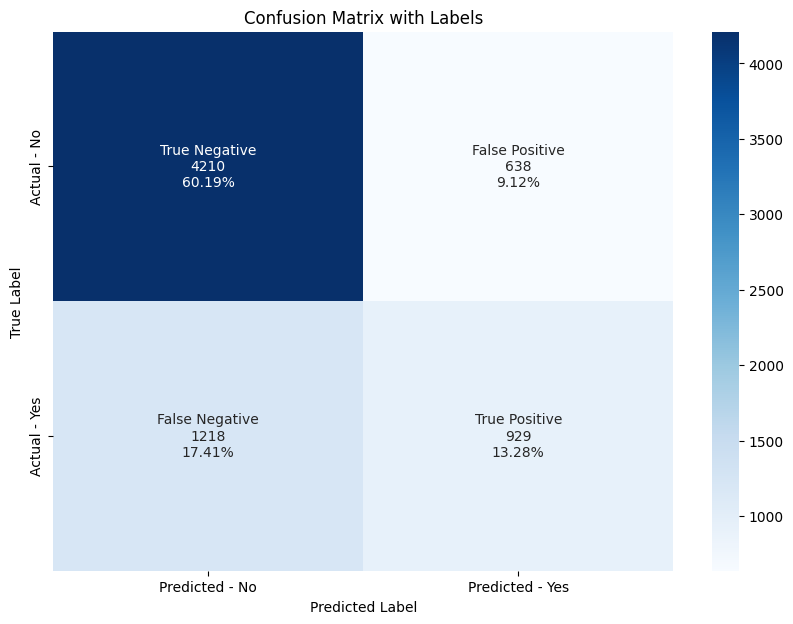

In [ ]:
make_confusion_matrix2(rf_estimator,X_test,y_test)

In [ ]:
rf_estimator_model_train_perf = model_performance_classification_sklearn(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:

rf_estimator_model_test_perf = model_performance_classification_sklearn(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.734668,0.432697,0.592853,0.500269


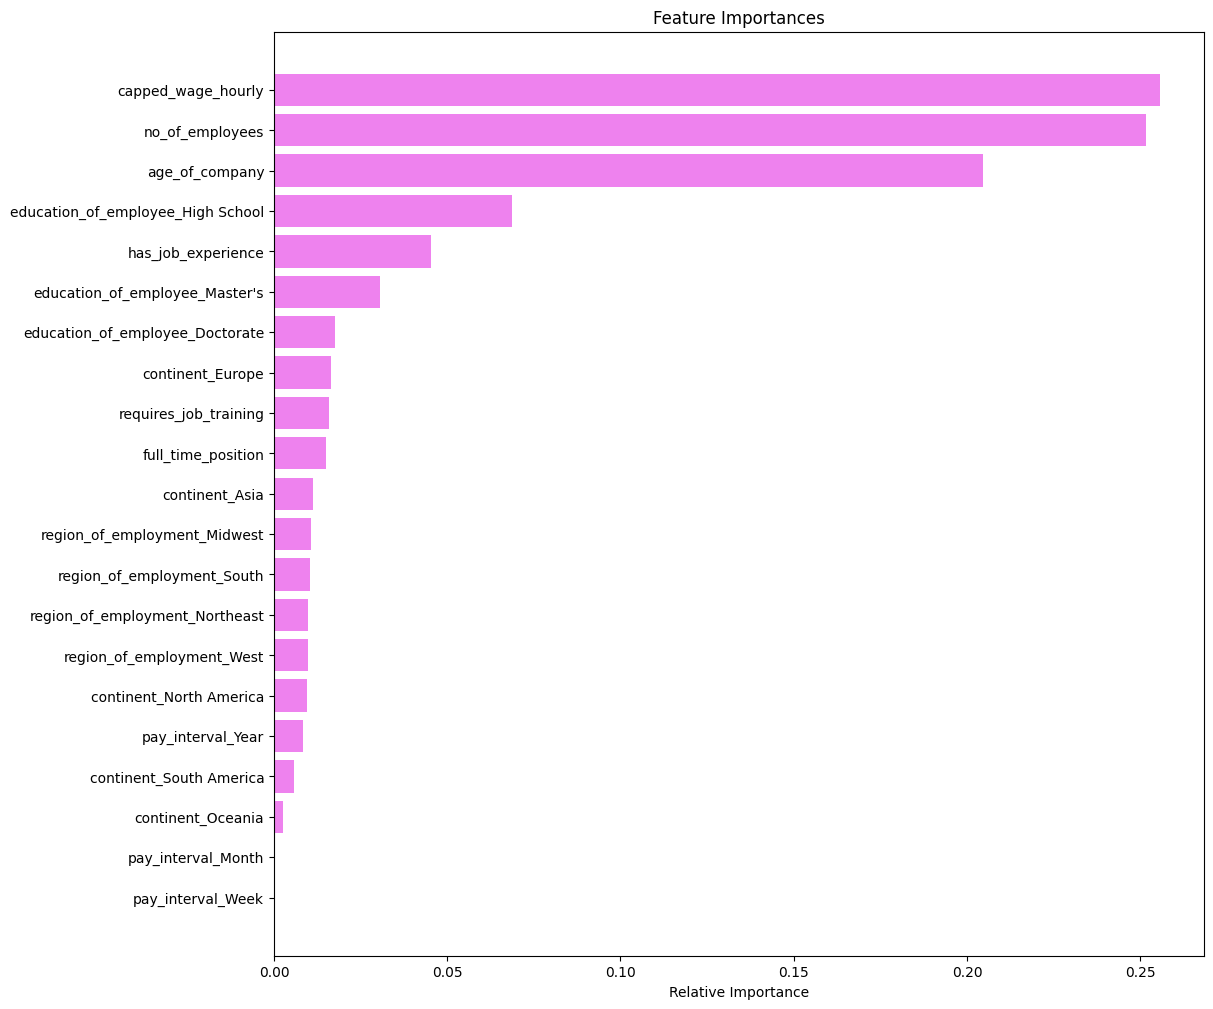

In [ ]:
importances = rf_estimator.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####Insight
Overfitting on the training set and mediocre performance on the test set.

In [ ]:
# Choose the type of classifier.
rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [0.3, 0.6, 0.1,'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(max_features=0.6, max_samples=0.6, min_samples_leaf=3,
                       n_estimators=50, random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
rf_estimator_tuned_score=get_metrics_score(rf_estimator_tuned)

Accuracy on training set :  0.8684516880093132
Accuracy on test set :  0.7471050750536097
Recall on training set :  0.6583466453674122
Recall on test set :  0.43735444806707036
Precision on training set :  0.8832038574872757
Precision on test set :  0.626


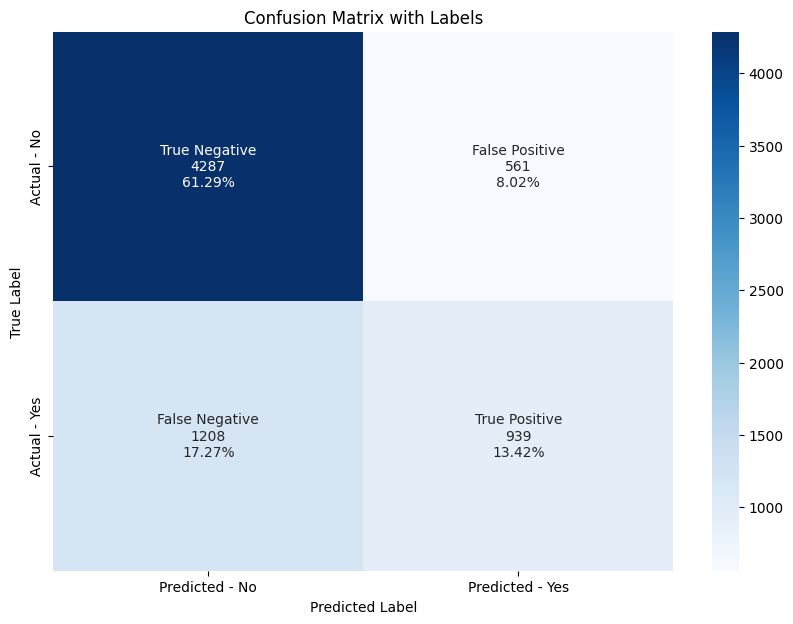

In [ ]:
#plot confusion matrix
make_confusion_matrix2(rf_estimator_tuned,X_test,y_test)

In [ ]:
rf_estimator_tuned_model_train_perf = model_performance_classification_sklearn(rf_estimator_tuned, X_train, y_train)
rf_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.868452,0.658347,0.883204,0.754376


In [ ]:
rf_estimator_tuned_model_test_perf = model_performance_classification_sklearn(rf_estimator_tuned, X_test, y_test)
rf_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.747105,0.437354,0.626,0.514944


## Boosting

###ADA Boost

In [ ]:
abc = AdaBoostClassifier(random_state=1)
abc.fit(X_train,y_train)

AdaBoostClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
abc_score=get_metrics_score(abc)

Accuracy on training set :  0.7444396789412413
Accuracy on test set :  0.74253037884203
Recall on training set :  0.3835862619808307
Recall on test set :  0.3721471821145785
Precision on training set :  0.6392678868552413
Precision on test set :  0.6381789137380192


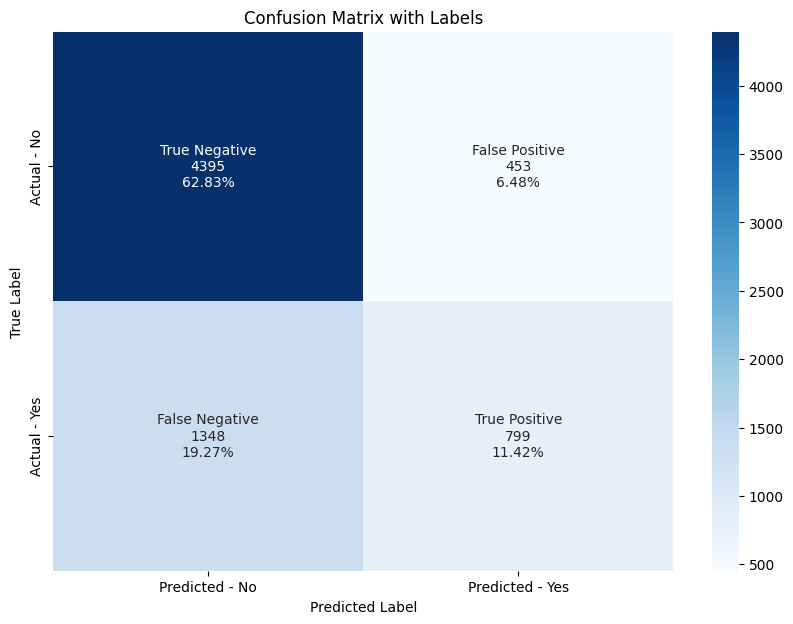

In [ ]:
make_confusion_matrix2(abc,X_test,y_test)

In [ ]:
abc_estimator_model_train_perf = model_performance_classification_sklearn(abc, X_train, y_train)
abc_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.74444,0.383586,0.639268,0.479471


In [ ]:
abc_estimator_model_test_perf = model_performance_classification_sklearn(abc, X_test, y_test)
abc_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.74253,0.372147,0.638179,0.470138


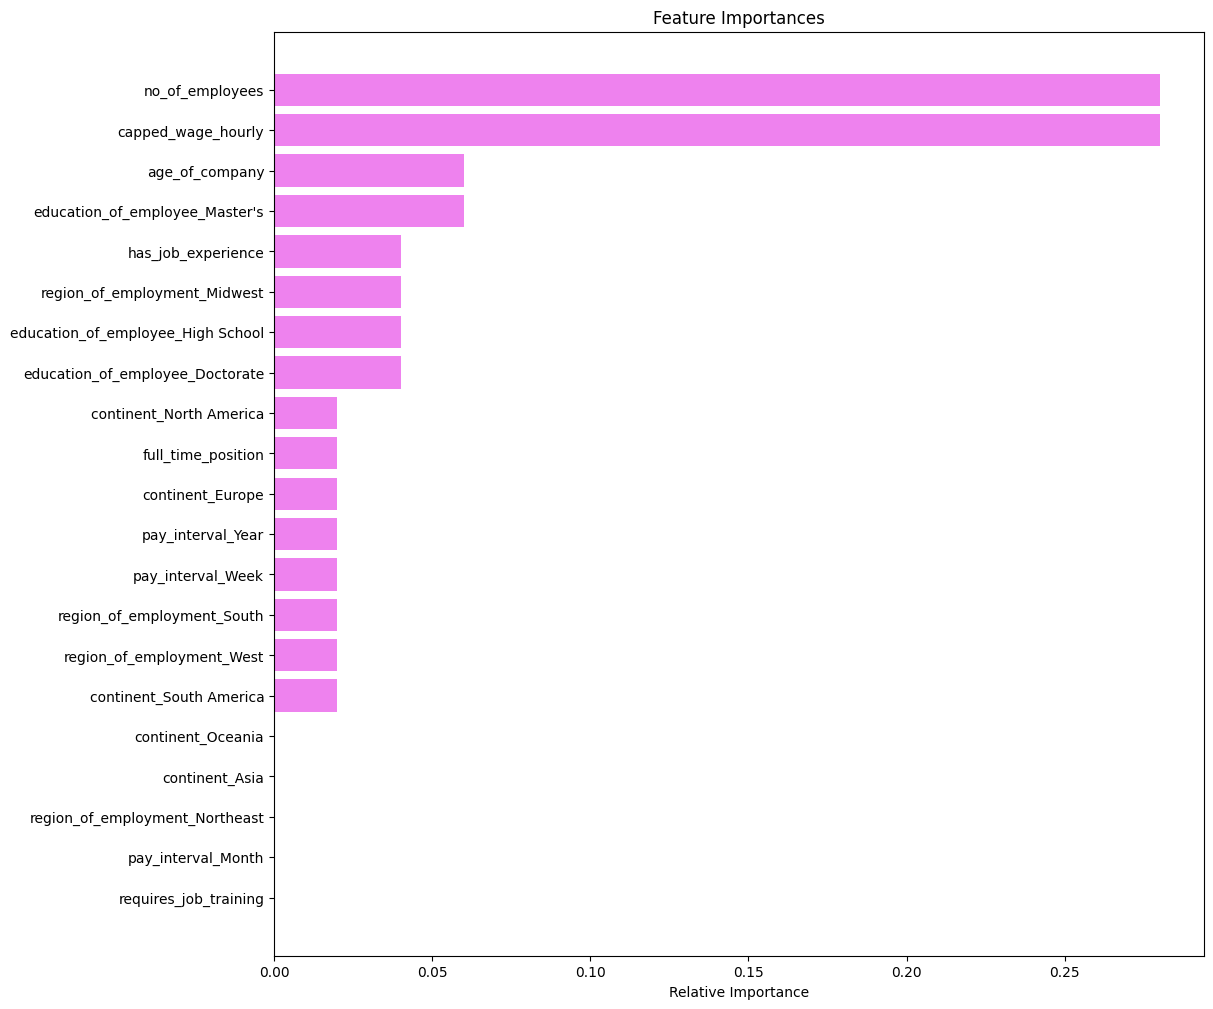

In [ ]:
importances = abc.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

###Gradient Boosting Classifier

### gbc default

In [ ]:
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(X_train,y_train)

GradientBoostingClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
gbc_score=get_metrics_score(gbc)

Accuracy on training set :  0.759879909319282
Accuracy on test set :  0.7565403859899928
Recall on training set :  0.448482428115016
Recall on test set :  0.4462040055891942
Precision on training set :  0.6600058771672054
Precision on test set :  0.6508152173913043


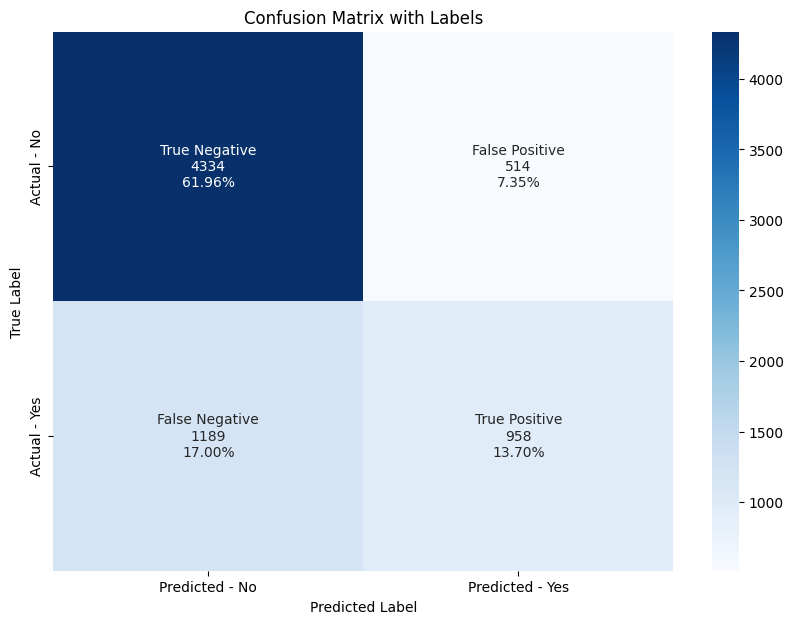

In [ ]:
make_confusion_matrix2(gbc,X_test,y_test)

In [ ]:
gbc_estimator_model_train_perf = model_performance_classification_sklearn(gbc, X_train, y_train)
gbc_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.75988,0.448482,0.660006,0.534063


In [ ]:
gbc_estimator_model_test_perf = model_performance_classification_sklearn(gbc, X_test, y_test)
gbc_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.75654,0.446204,0.650815,0.529428


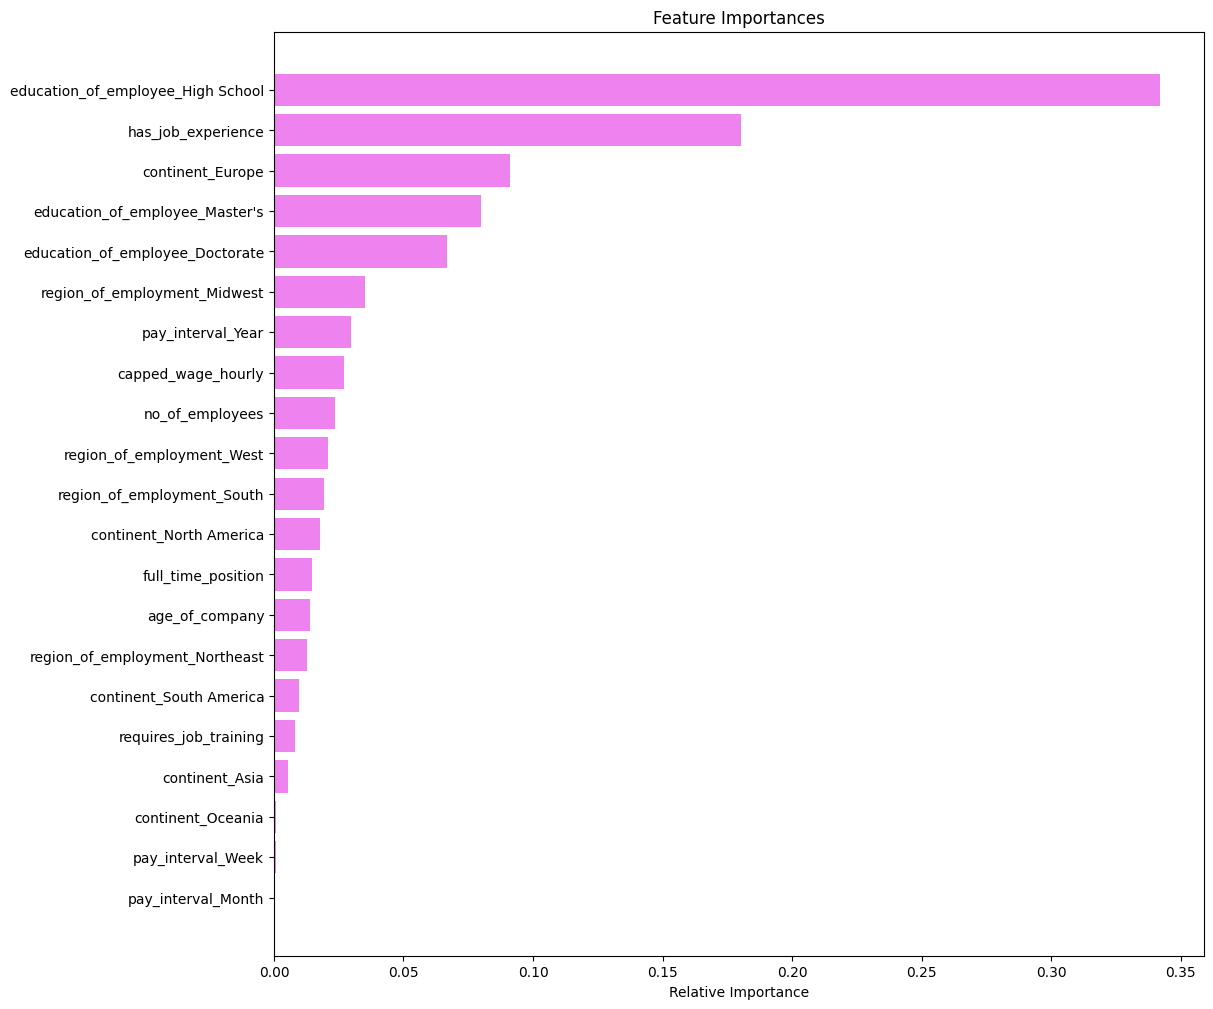

In [ ]:
importances = gbc.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

###XG Boost Classifier

### xgb default

In [ ]:
xgb = XGBClassifier(random_state=1,eval_metric='logloss')
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
xgb_score=get_metrics_score(xgb)

Accuracy on training set :  0.8522149378101832
Accuracy on test set :  0.7348105789849892
Recall on training set :  0.6383785942492013
Recall on test set :  0.42897065673032136
Precision on training set :  0.8417588204318062
Precision on test set :  0.5941935483870968


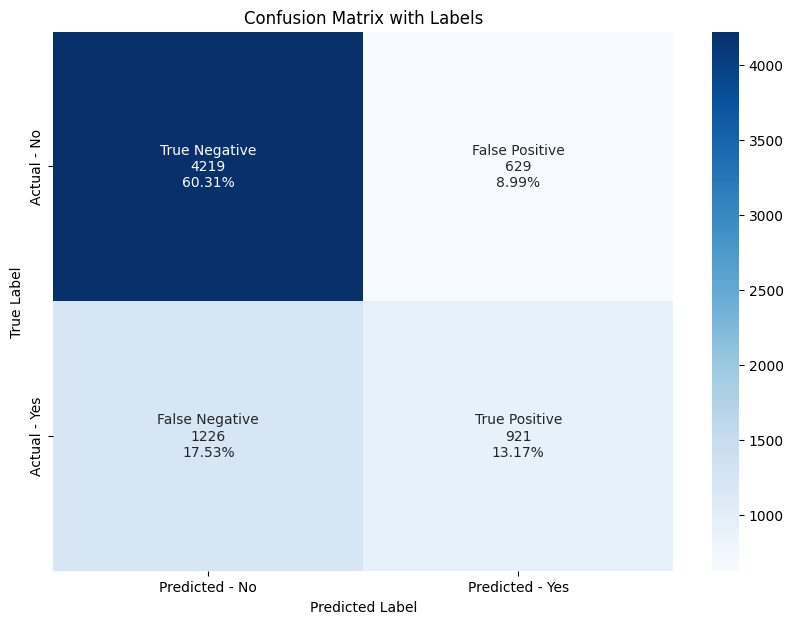

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
make_confusion_matrix2(xgb,X_test,y_test)

In [ ]:
xgb_estimator_model_train_perf = model_performance_classification_sklearn(xgb, X_train, y_train)
abc_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.74444,0.383586,0.639268,0.479471


In [ ]:
xgb_estimator_model_test_perf = model_performance_classification_sklearn(xgb, X_test, y_test)
xgb_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.734811,0.428971,0.594194,0.498242


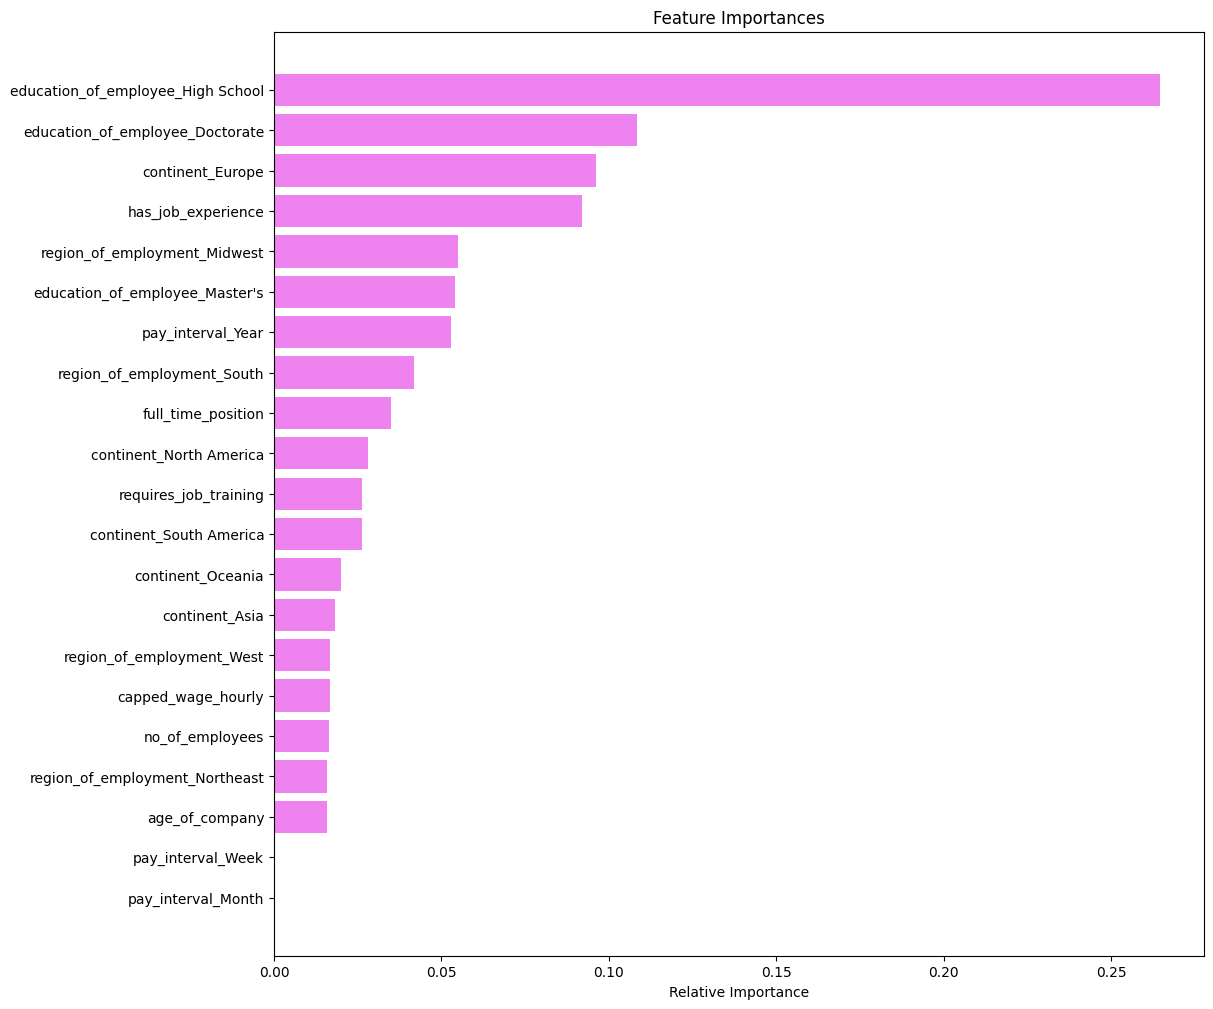

In [ ]:
importances = xgb.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

##  Will tuning the hyperparameters improve the model performance?

##Bagging Tuned

In [ ]:
# Choose the type of classifier.
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.9, max_samples=0.9, n_estimators=70,
                  random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_tuned_score=get_metrics_score(bagging_estimator_tuned)

Accuracy on training set :  0.9995711047117211
Accuracy on test set :  0.7409578270192995
Recall on training set :  0.9986022364217252
Recall on test set :  0.4047508150908244
Precision on training set :  1.0
Precision on test set :  0.6193870277975766


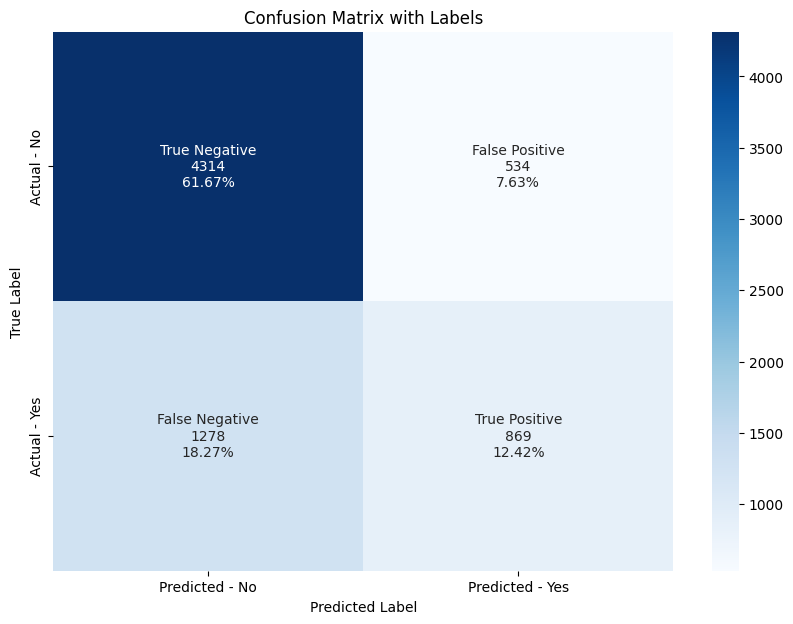

In [ ]:
#plot confusion matrix
make_confusion_matrix2(bagging_estimator_tuned,X_test,y_test)

In [ ]:
bagging_estimator_tuned_model_train_perf = model_performance_classification_sklearn(bagging_estimator_tuned, X_train, y_train)
bagging_estimator_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.999571,0.998602,1.0,0.999301


In [ ]:


bagging_estimator_tuned_model_test_perf = model_performance_classification_sklearn(bagging_estimator_tuned, X_test, y_test)
bagging_estimator_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.740958,0.404751,0.619387,0.489577


##Boosting Tuned

In [ ]:
#suppress warnings about future code changes
import warnings
warnings.filterwarnings("ignore")

###ADA Boost Tuned

In [ ]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {

      "n_estimators": np.arange(50,110,25),
      "learning_rate": [0.01,0.1,0.05],
      "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
          ],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=0.1, n_estimators=75, random_state=1)

In [ ]:
abc_tuned_score=get_metrics_score(abc_tuned)

Accuracy on training set :  0.7597573678083451
Accuracy on test set :  0.7555396711937098
Recall on training set :  0.44508785942492013
Recall on test set :  0.44108057755006985
Precision on training set :  0.6612281222189261
Precision on test set :  0.6499656829100893


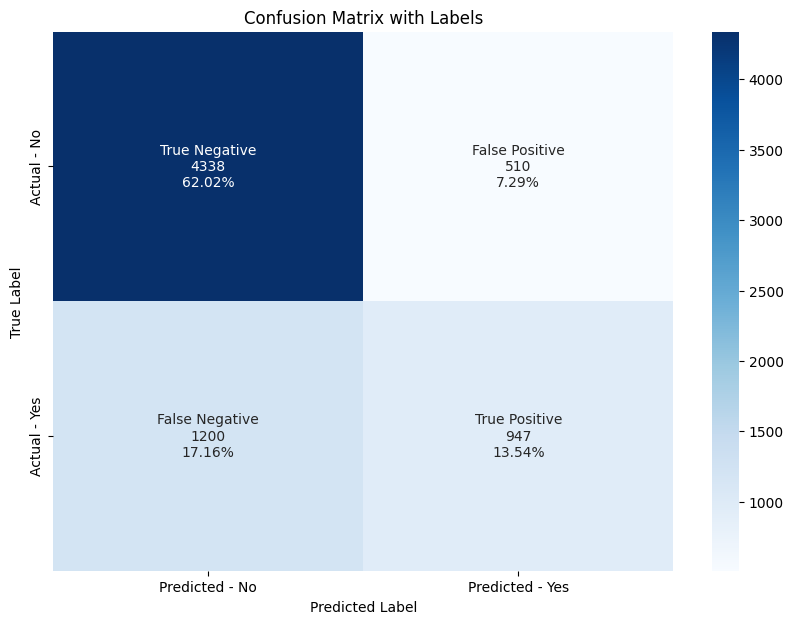

In [ ]:
make_confusion_matrix2(abc_tuned,X_test,y_test)

In [ ]:
abc_tuned_estimator_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)
abc_tuned_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.759757,0.445088,0.661228,0.532044


In [ ]:
abc_tuned_estimator_model_test_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
abc_tuned_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.75554,0.441081,0.649966,0.525527


###Gradient Boosting Tuned

####GB default tuned


In [ ]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [50,110,25],
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

GradientBoostingClassifier(max_features=0.5, n_estimators=110, random_state=1,
                           subsample=0.7)

In [ ]:
gbc_tuned_score=get_metrics_score(gbc_tuned)

Accuracy on training set :  0.7592059310091294
Accuracy on test set :  0.7568263045032165
Recall on training set :  0.4476837060702875
Recall on test set :  0.4471355379599441
Precision on training set :  0.6582501467997651
Precision on test set :  0.6512890094979648


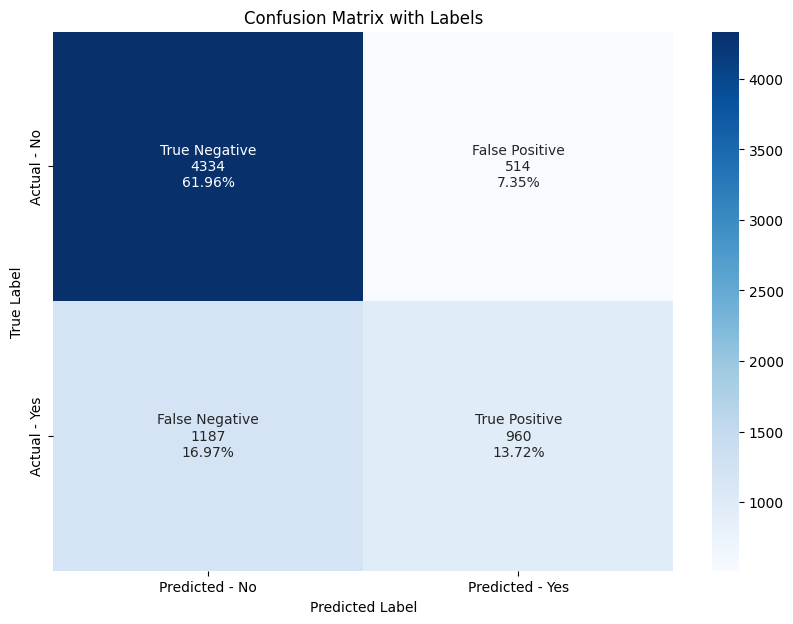

In [ ]:
make_confusion_matrix2(gbc_tuned,X_test,y_test)

In [ ]:
gbc_tuned_estimator_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)
gbc_tuned_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.759206,0.447684,0.65825,0.532921


In [ ]:
gbc_tuned_estimator_model_test_perf = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)
gbc_tuned_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.756826,0.447136,0.651289,0.53024


####GB Init tuned

In [ ]:
# Choose the type of classifier.
gbc_init = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [50,110,25],
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_init = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_init.fit(X_train, y_train)

GradientBoostingClassifier(max_features=0.5, n_estimators=110, random_state=1,
                           subsample=0.7)

In [ ]:
gbc_score=get_metrics_score(gbc_init)

Accuracy on training set :  0.7592059310091294
Accuracy on test set :  0.7568263045032165
Recall on training set :  0.4476837060702875
Recall on test set :  0.4471355379599441
Precision on training set :  0.6582501467997651
Precision on test set :  0.6512890094979648


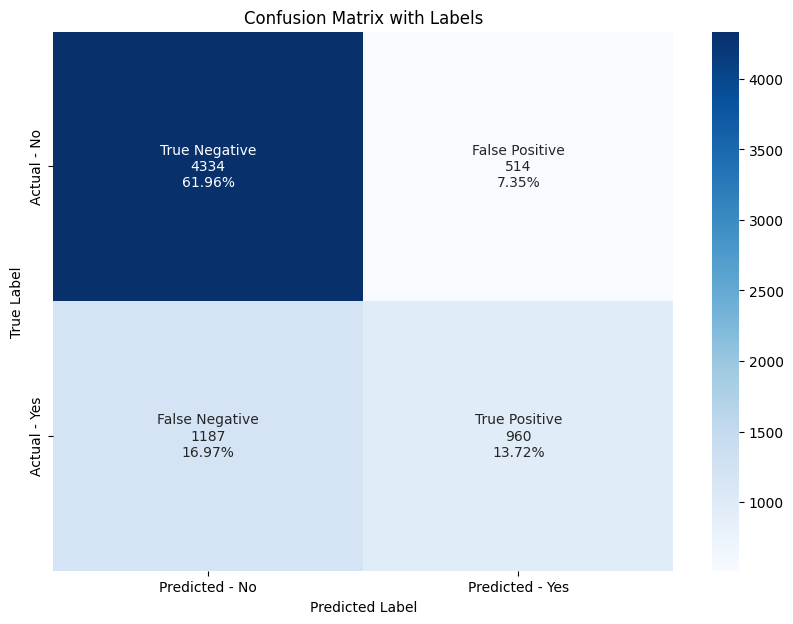

In [ ]:
make_confusion_matrix2(gbc_init,X_test,y_test)

In [ ]:
gbc_init_estimator_model_train_perf = model_performance_classification_sklearn(gbc_init, X_train, y_train)
gbc_init_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.759206,0.447684,0.65825,0.532921


In [ ]:
gbc_init_estimator_model_test_perf = model_performance_classification_sklearn(gbc_init, X_test, y_test)
gbc_init_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.756826,0.447136,0.651289,0.53024


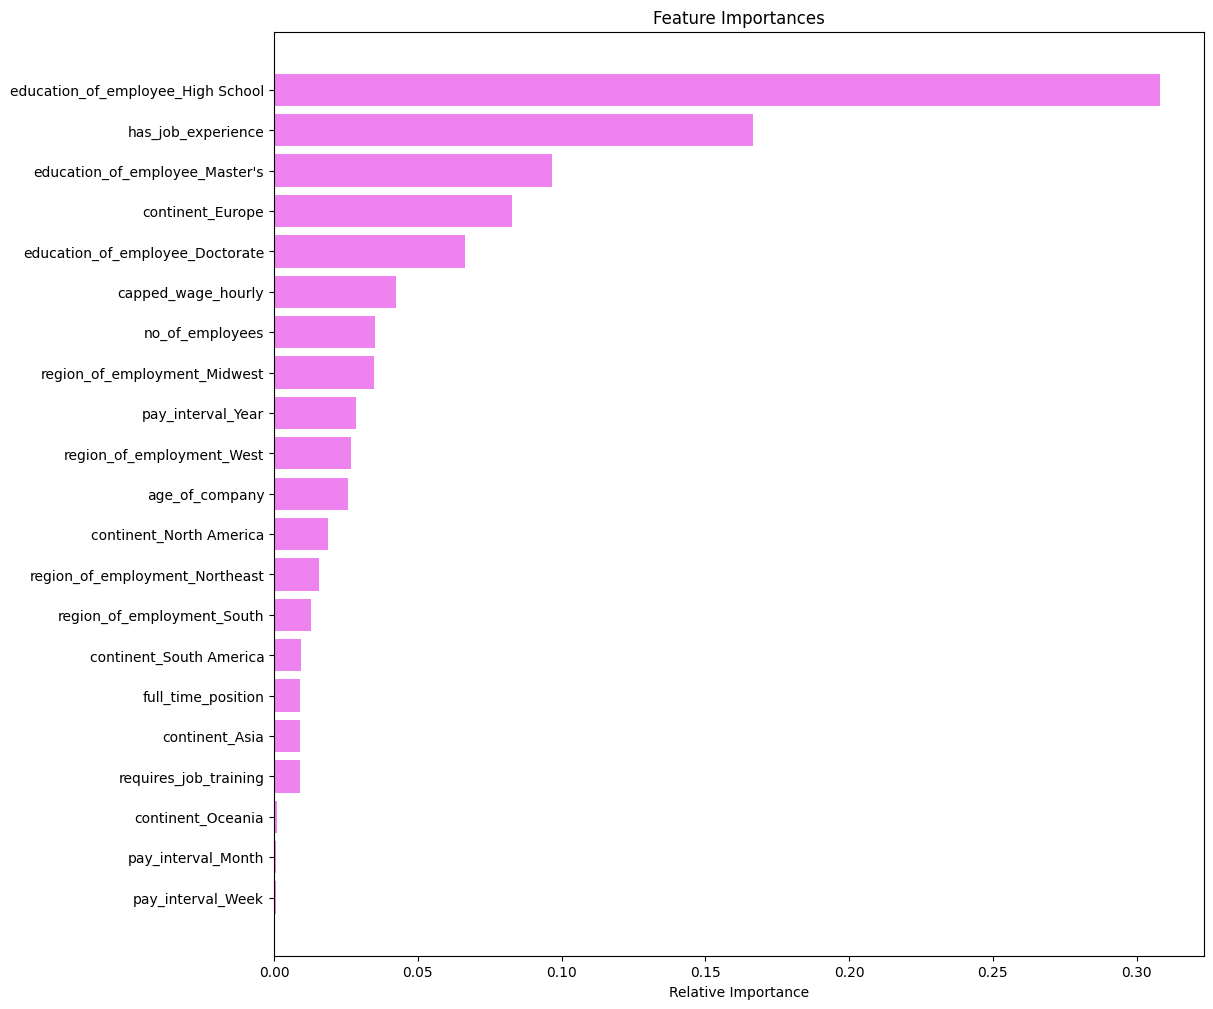

In [ ]:
importances = gbc_init.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

###XG Boost Tuned

In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1,eval_metric='logloss')

# Grid of parameters to choose from
## add from
parameters = {'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters,scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb_tuned_score=get_metrics_score(xgb_tuned)

Accuracy on training set :  0.4240548985968997
Accuracy on test set :  0.4220157255182273
Recall on training set :  0.994408945686901
Recall on test set :  0.9906846762925011
Precision on training set :  0.34698996655518394
Precision on test set :  0.34585365853658534


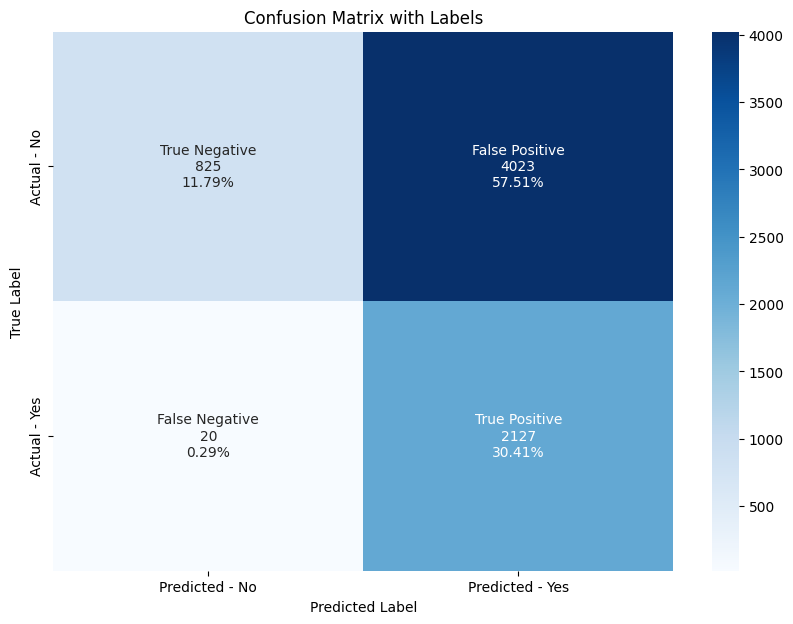

In [ ]:
make_confusion_matrix2(xgb_tuned,X_test,y_test)

In [ ]:
xgb_tuned_estimator_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
xgb_tuned_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.424055,0.994409,0.34699,0.514463


In [ ]:
xgb_tuned_estimator_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
xgb_tuned_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.422016,0.990685,0.345854,0.512715


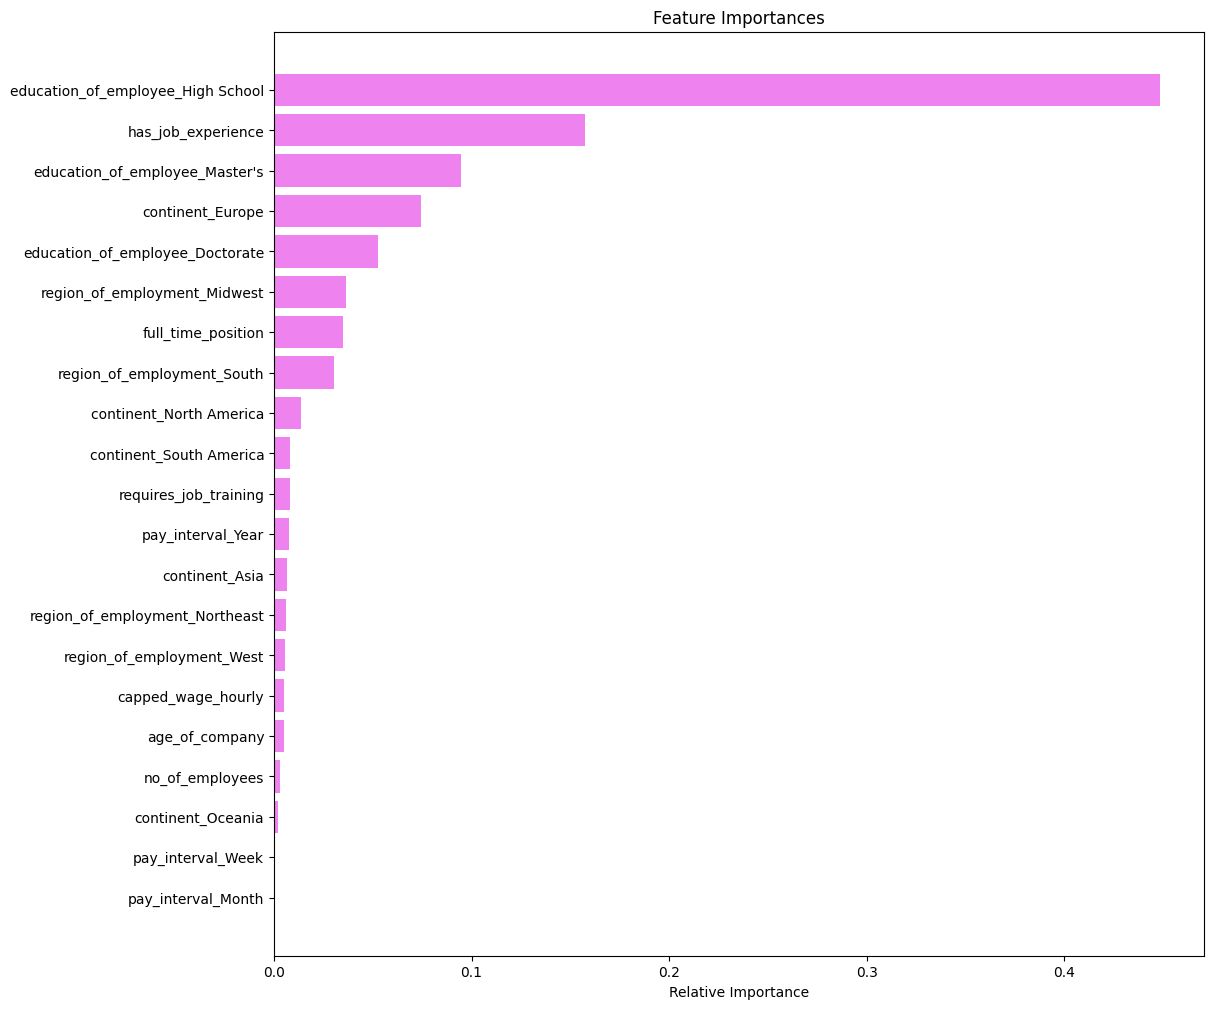

In [ ]:
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
estimators = [
    ("AdaBoost", abc_tuned),
    ("Gradient Boosting", gbc_tuned),
    ("Random Forest", rf_estimator_tuned),
]

final_estimator = xgb_tuned

stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

stacking_classifier.fit(X_train, y_train)

StackingClassifier(estimators=[('AdaBoost',
                                AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                                                         random_state=1),
                                                   learning_rate=0.1,
                                                   n_estimators=75,
                                                   random_state=1)),
                               ('Gradient Boosting',
                                GradientBoostingClassifier(max_features=0.5,
                                                           n_estimators=110,
                                                           random_state=1,
                                                           subsample=0.7)),
                               ('Random Forest',
                                RandomForestClassifier(max_features=0.6,
                                                       max...
                                                 feature_types=None, gamma=1,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.01,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=50, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=1, ...))

In [ ]:
stacking_classifier_model_train_perf = model_performance_classification_sklearn(stacking_classifier, X_train, y_train)
stacking_classifier_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.407144,1.0,0.341051,0.508633


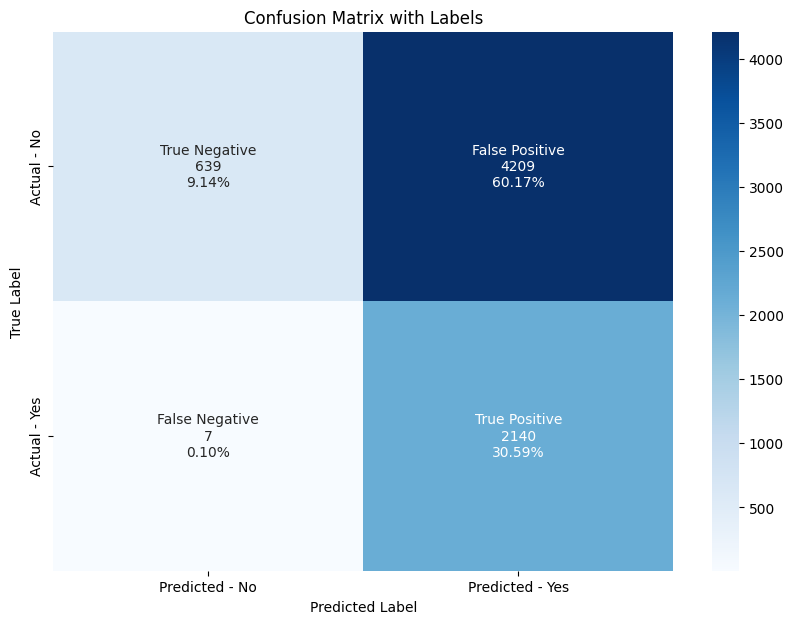

In [ ]:
make_confusion_matrix2(stacking_classifier,X_test,y_test)

In [ ]:
stacking_classifier_model_test_perf = model_performance_classification_sklearn(stacking_classifier, X_test, y_test)
stacking_classifier_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.397284,0.99674,0.337061,0.503766


## Model Performance Comparison and Conclusions

Looking at performances over test and training models

In [ ]:
# defining list of models
models = [dtree,dtree_tuned,bagging_estimator,bagging_estimator_tuned,abc, abc_tuned, gbc,gbc_init, gbc_tuned, xgb, xgb_tuned]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the accuracy, precall and precision scores
for model in models:
    j = get_metrics_score(model,False)
    acc_train.append(np.round(j[0],2))
    acc_test.append(np.round(j[1],2))
    recall_train.append(np.round(j[2],2))
    recall_test.append(np.round(j[3],2))
    precision_train.append(np.round(j[4],2))
    precision_test.append(np.round(j[5],2))

In [ ]:
comparison_frame = pd.DataFrame({'Model':['Decision Tree with default parameters',
                                          'Decision Tree Tuned',
                                          'Bagging with default parameters',
                                          'Bagging Tuned',
                                          'AdaBoost with default paramters',
                                          'AdaBoost Tuned',
                                          'Gradient Boosting with default parameters',
                                          'Gradient Boosting with init=AdaBoost',
                                          'Gradient Boosting Tuned',
                                          'XGBoost with default parameters',
                                          'XGBoost Tuned'],
                                          'Train_Accuracy': acc_train,'Test_Accuracy': acc_test,
                                          'Train_Recall':recall_train,'Test_Recall':recall_test,
                                          'Train_Precision':precision_train,'Test_Precision':precision_test})
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Decision Tree with default parameters,1.00,0.67,1.00,0.48,1.00,0.46
1,Decision Tree Tuned,0.74,0.74,0.52,0.52,0.58,0.58
2,Bagging with default parameters,0.98,0.72,0.94,0.39,0.99,0.57
3,Bagging Tuned,1.00,0.74,1.00,0.40,1.00,0.62
4,AdaBoost with default paramters,0.74,0.74,0.38,0.37,0.64,0.64
5,AdaBoost Tuned,0.76,0.76,0.45,0.44,0.66,0.65
6,Gradient Boosting with default parameters,0.76,0.76,0.45,0.45,0.66,0.65
7,Gradient Boosting with init=AdaBoost,0.76,0.76,0.45,0.45,0.66,0.65
8,Gradient Boosting Tuned,0.76,0.76,0.45,0.45,0.66,0.65
9,XGBoost with default parameters,0.85,0.73,0.64,0.43,0.84,0.59


In [ ]:
models_train_comp_df = pd.concat(
    [
        dtree_estimator_model_train_perf.T,
        dtree_tuned_model_train_perf.T,
        bagging_estimator_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
        rf_estimator_tuned_model_train_perf.T,
        abc_estimator_model_train_perf.T,
        abc_tuned_estimator_model_train_perf.T,
        gbc_estimator_model_train_perf.T,
        gbc_init_estimator_model_train_perf.T,
        gbc_tuned_estimator_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        xgb_tuned_estimator_model_train_perf.T,
        stacking_classifier_model_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Gradient Boost with Init",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Tuned Decision Tree,Bagging Classifier,Tuned Bagging Classifier,Random Forest,Tuned Random Forest,Adaboost Classifier,Tuned Adaboost Classifier,Gradient Boost Classifier,Gradient Boost with Init,Tuned Gradient Boost Classifier,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,1.0,0.738619,0.978862,0.999571,1.0,0.868452,0.744440,0.759757,0.759880,0.759206,0.759206,0.852215,0.424055,0.407144
Recall,1.0,0.515375,0.938898,0.998602,1.0,0.658347,0.383586,0.445088,0.448482,0.447684,0.447684,0.638379,0.994409,1.000000
Precision,1.0,0.583937,0.991774,1.000000,1.0,0.883204,0.639268,0.661228,0.660006,0.658250,0.658250,0.841759,0.346990,0.341051
F1,1.0,0.547518,0.964612,0.999301,1.0,0.754376,0.479471,0.532044,0.534063,0.532921,0.532921,0.726096,0.514463,0.508633


In [ ]:
models_test_comp_df = pd.concat(
    [
        dtree_estimator_model_test_perf.T,
        dtree_tuned_model_test_perf.T,
        bagging_estimator_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
        rf_estimator_tuned_model_test_perf.T,
        abc_estimator_model_test_perf.T,
        abc_tuned_estimator_model_test_perf.T,
        gbc_estimator_model_test_perf.T,
        gbc_init_estimator_model_test_perf.T,
        gbc_tuned_estimator_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        xgb_tuned_estimator_model_test_perf.T,
        stacking_classifier_model_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Gradient Boost with Init",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Tuned Decision Tree,Bagging Classifier,Tuned Bagging Classifier,Random Forest,Tuned Random Forest,Adaboost Classifier,Tuned Adaboost Classifier,Gradient Boost Classifier,Gradient Boost with Init,Tuned Gradient Boost Classifier,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,0.668192,0.668192,0.723231,0.740958,0.734668,0.747105,0.742530,0.755540,0.756540,0.756826,0.756826,0.734811,0.422016,0.397284
Recall,0.475082,0.475082,0.393107,0.404751,0.432697,0.437354,0.372147,0.441081,0.446204,0.447136,0.447136,0.428971,0.990685,0.996740
Precision,0.460705,0.460705,0.571429,0.619387,0.592853,0.626000,0.638179,0.649966,0.650815,0.651289,0.651289,0.594194,0.345854,0.337061
F1,0.467783,0.467783,0.465784,0.489577,0.500269,0.514944,0.470138,0.525527,0.529428,0.530240,0.530240,0.498242,0.512715,0.503766


####Insight

*   Gradient boosting seems to perform the best with a balance of high accuracy, precision and F1 scores (0.533-0.535).
*   Adaboost showed good balance of accuracy and precision.
*   Random forest performed reasonably well especially after tuning.
*   Bagging models were good on accuracy and precision, but had lower recall.
*   XG boost shows signs of overfitting after tuning with a high recall score, but low accuracy and precision.
*   Decision trees performed poorly even after tuning.








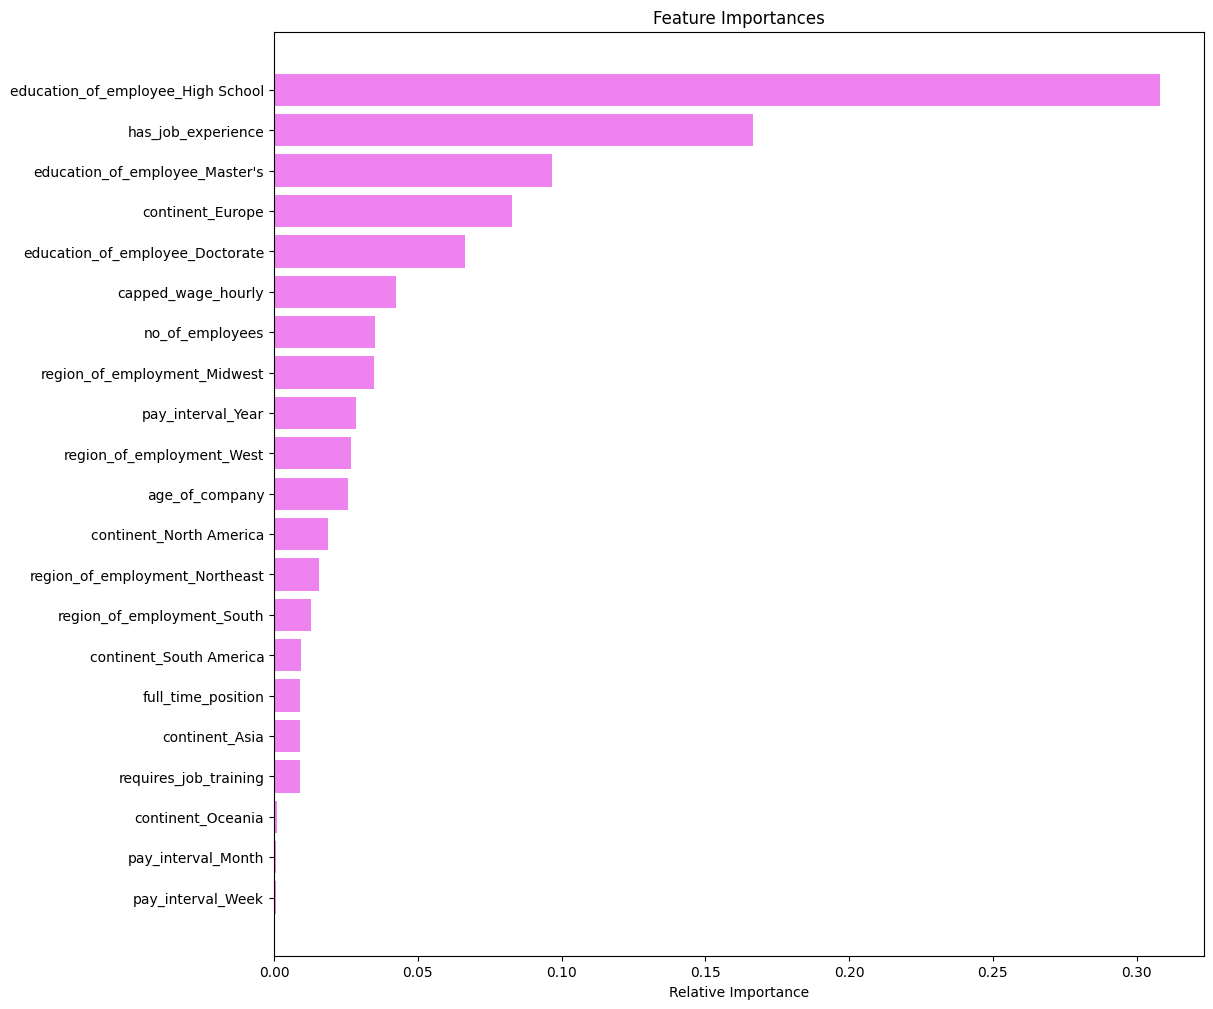

In [ ]:
feature_names = X_train.columns
importances = gbc_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

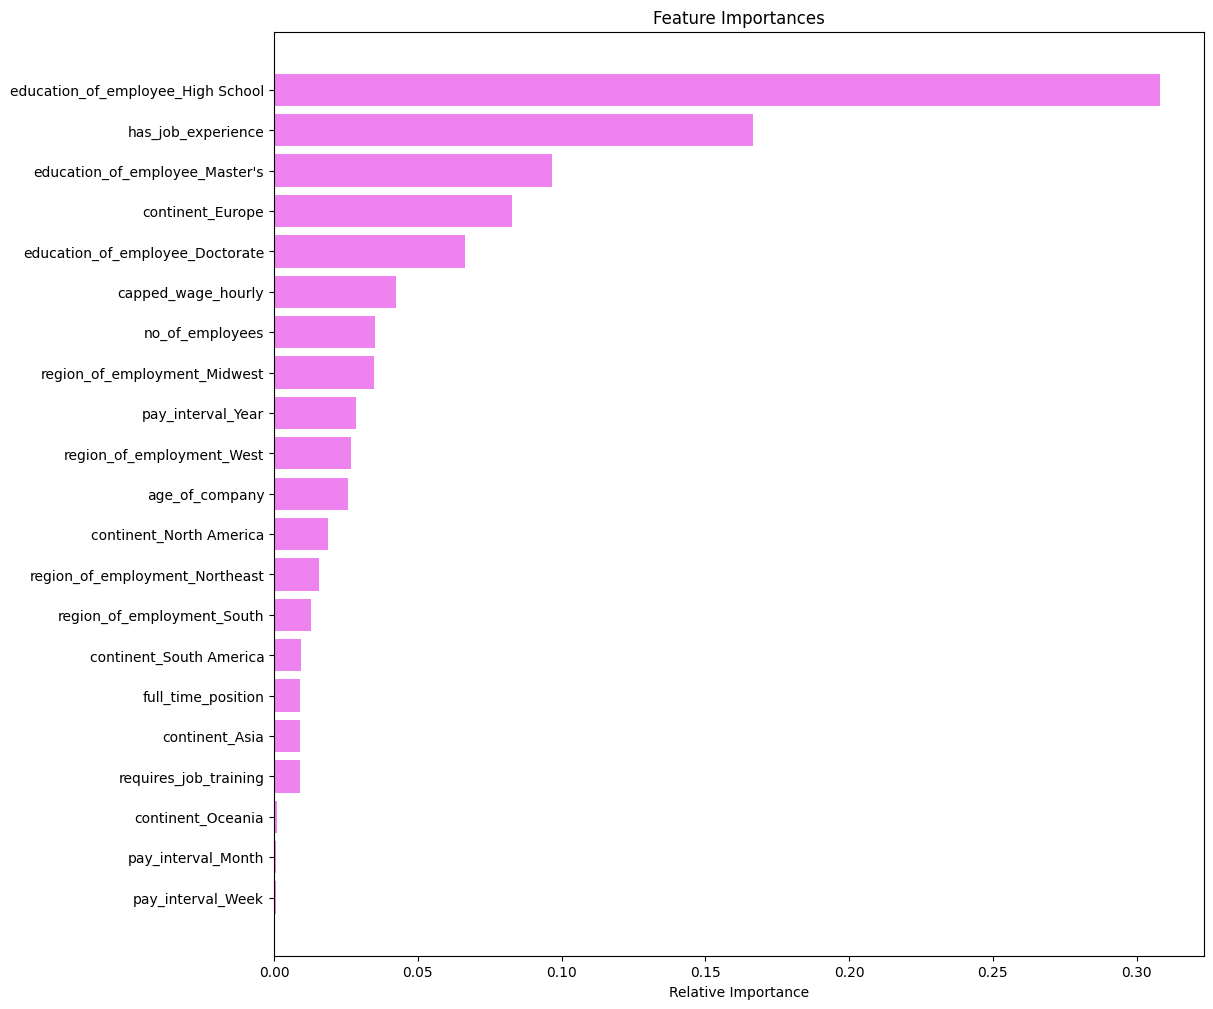

In [ ]:
feature_names = X_train.columns
importances = gbc_init.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Recommendations

Looking at the best performing gradient boost models, it is apparent that the education level of the candidate is the most important feature. The market seems to favor less experienced candidates with a high school education with a slight preference for candidates from Asia. Yearly pay intervals are also an important factor.